# AEROVALE Airport

### 1. Selection of Future Use Cases for AEROVALE Airport

#### 1.1 Future Use Cases for Strategic Planning
1. **Urban Air Mobility (UAM)** using eVTOL aircraft  
2. **Uncrewed Aerial Vehicle (UAV) Operations** for cargo and medical logistics

#### 1.2 Relevant Airport Users
- eVTOL aircraft operators for passenger transport (short-range)
- Cargo drone operators
- Medical logistics providers
- Government agencies for surveillance and emergency services

#### 1.3 Required Airside Infrastructure
To accommodate these new users, the following airside infrastructure is required:
- **Vertiports / landing pads** for eVTOL operations
- **Dedicated UAV operation zones** including launch and landing areas
- **Modified taxiways and stands** adapted to smaller aircraft
- **Separation infrastructure** to ensure safe coexistence with conventional aircraft

#### 1.4 Main Assumptions
- Demand for UAM and UAV operations will increase over the planning horizon
- New operations will complement, not replace, conventional aviation
- Infrastructure can be integrated into existing airside areas with modifications


### 2. Generation of Future Demand Scenarios

#### 2.1 Setup and Data Import


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from itertools import product


##### Import of Historical Airport Demand Data

The historical dataset contains the annual observations that are used to calibrate the stochastic model. The main columns are `Year`, `Passengers`, and `Flight_Movements`, and the file is read with `;` as delimiter.


In [2]:
# Load the historical airport dataset once at the start of the notebook
historical_df = pd.read_csv("aerovale_demand.csv", delimiter=";")

# Display the first rows to verify the structure of the input data
historical_df.head()


,Year,Flight_Movements,Passengers
0,1982,18500,210000
1,1983,18800,218000
2,1984,19100,225000
3,1985,19500,235000
4,1986,19800,245000


#### 2.2 Selection of Historical Sample and Estimation of GBM Parameters


 The historical sample used for calibration can be chosen either with or without the COVID years 2020 to 2022 as they can be seen as an exceptional shock. After the sample is selected, the annual passenger and flight-movement series are converted into log returns, and the GBM drift `μ` and volatility `σ` are estimated from these returns.
 

In [3]:
# Choose the historical sample used for calibration
# Either chose False or True to exclude or include the COVID years
include_covid_years = False
covid_years = [2020, 2021, 2022]

if include_covid_years:
    historical_sample_df = historical_df.copy()
    sample_label = "including COVID years"
else:
    historical_sample_df = historical_df[~historical_df["Year"].isin(covid_years)].copy()
    sample_label = "excluding COVID years"

years = historical_sample_df["Year"].to_numpy()
demand = historical_sample_df["Passengers"].to_numpy()
flt_movements = historical_sample_df["Flight_Movements"].to_numpy()

# Convert historical levels into annual log returns
log_returns_demand = np.log(demand[1:] / demand[:-1])
log_returns_flt = np.log(flt_movements[1:] / flt_movements[:-1])

# Estimate GBM parameters from the log-return series
mu_hat_demand = np.mean(log_returns_demand)
sigma_hat_demand = np.std(log_returns_demand)
mu_hat_flt = np.mean(log_returns_flt)
sigma_hat_flt = np.std(log_returns_flt)

print("Selected historical sample:", sample_label)
print("Years used:", years[0], "to", years[-1])
print("Number of observations:", len(years))
print()
print("Estimated GBM parameters for passenger demand:")
print("  mu    =", mu_hat_demand)
print("  sigma =", sigma_hat_demand)
print()
print("Estimated GBM parameters for flight movements:")
print("  mu    =", mu_hat_flt)
print("  sigma =", sigma_hat_flt)


Selected historical sample: excluding COVID years
Years used: 1982 to 2024
Number of observations: 40

Estimated GBM parameters for passenger demand:
  mu    = 0.03702856235919787
  sigma = 0.031076412456896317

Estimated GBM parameters for flight movements:
  mu    = 0.015224992480685682
  sigma = 0.016129268249050505


#### 2.3 Simulation of Future Demand and Flight-Movement Scenarios


The simulation starts from the last observed historical value and generates one annual GBM step per year over the planning horizon. Separate scenario sets are created for passenger demand and for flight movements so that both variables can later be used in the market-share and real-options analysis.

Each scenario matrix has shape `(horizon_years + 1, n_scenarios)`. Row 0 contains the last observed historical value, and each following row contains the simulated value one year later.


In [4]:
def simulate_gbm_paths(initial_value, mu_hat, sigma_hat, horizon_years, n_scenarios, dt=1):
    """Simulate annual GBM paths.

    Row 0 stores the last observed historical value, so the simulated paths
    can be plotted continuously together with the historical series.
    """
    paths = np.zeros((horizon_years + 1, n_scenarios))
    paths[0, :] = initial_value

    for t in range(1, horizon_years + 1):
        random_shocks = np.random.normal(0, 1, n_scenarios)
        growth_factor = np.exp(mu_hat * dt + sigma_hat * random_shocks * np.sqrt(dt))
        paths[t, :] = paths[t - 1, :] * growth_factor

    return paths


# Simulation settings
n_scenarios = 1000
horizon_years = 20
dt = 1

# Start each simulation from the last observed historical value
initial_demand = demand[-1]
initial_flt_movements = flt_movements[-1]

# Simulate separate GBM scenario sets for passengers and flight movements
scenarios_demand = simulate_gbm_paths(
    initial_value=initial_demand,
    mu_hat=mu_hat_demand,
    sigma_hat=sigma_hat_demand,
    horizon_years=horizon_years,
    n_scenarios=n_scenarios,
    dt=dt,
)

scenarios_flt = simulate_gbm_paths(
    initial_value=initial_flt_movements,
    mu_hat=mu_hat_flt,
    sigma_hat=sigma_hat_flt,
    horizon_years=horizon_years,
    n_scenarios=n_scenarios,
    dt=dt,
)

print("Passenger-demand scenario matrix:", scenarios_demand.shape)
print("Flight-movement scenario matrix:", scenarios_flt.shape)


Passenger-demand scenario matrix: (21, 1000)
Flight-movement scenario matrix: (21, 1000)


#### 2.4 Summary Statistics of the Simulated Scenarios


For each forecast year, the mean across all simulated paths represents the expected trajectory, while the standard deviation measures the uncertainty around that expectation. These summary series are reused in the plots below and in later parts of the notebook.

In [5]:
# Compute the expected path and uncertainty band for each forecast year
mean_demand = scenarios_demand.mean(axis=1)
std_demand = scenarios_demand.std(axis=1)

mean_flt = scenarios_flt.mean(axis=1)
std_flt = scenarios_flt.std(axis=1)

# Create the calendar-year axis once so it can be reused later in the notebook
future_years = np.arange(years[-1], years[-1] + horizon_years + 1)

# Compact summary table for interpretation and later reference
scenario_summary = pd.DataFrame(
    {
        "Mean passenger demand": mean_demand,
        "Std. passenger demand": std_demand,
        "Mean flight movements": mean_flt,
        "Std. flight movements": std_flt,
    },
    index=future_years,
)
scenario_summary.index.name = "Year"
scenario_summary.round(2)


,Mean passenger demand,Std. passenger demand,Mean flight movements,Std. flight movements
Year,,,,
2024,890000.00,0.00,33500.00,0.00
2025,923536.52,29090.84,34025.29,545.97
2026,960691.61,42786.88,34578.85,800.69
2027,997226.27,54730.62,35109.60,984.01
2028,1036483.52,65665.16,35678.49,1155.32
2029,1076781.51,76905.11,36249.01,1281.30
2030,1117647.98,86050.83,36805.77,1456.95
2031,1160460.49,95985.78,37382.94,1597.69
2032,1205081.78,105458.94,37949.69,1747.91


#### 2.5 Visualization of Historical Data and Simulated Scenario Paths


The plots show historical observations, a limited subset of simulated future paths to illustrate scenario dispersion, the mean and the corresponding standard-deviation band of all simulated scenarios

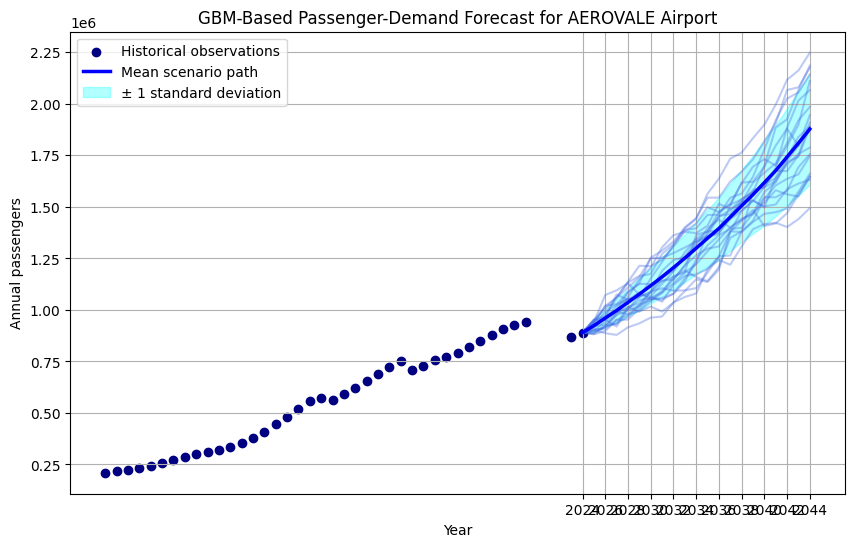

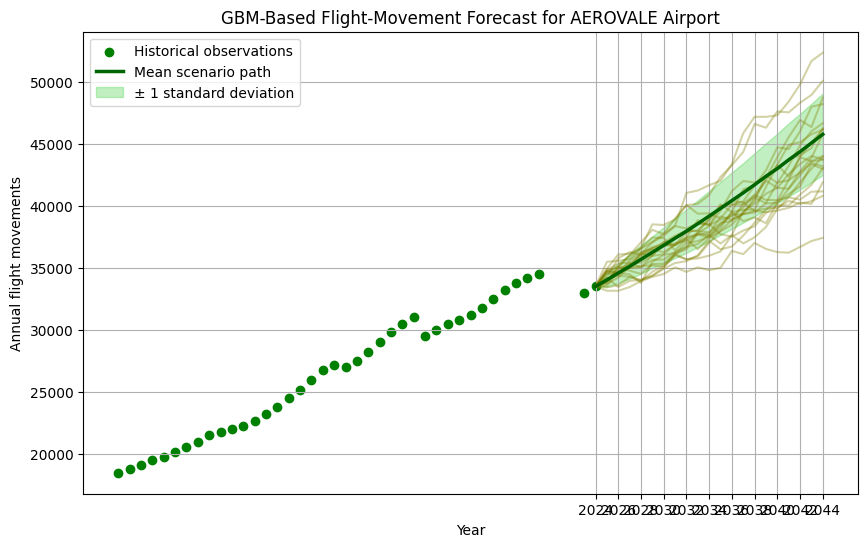

In [6]:
def plot_historical_and_gbm_forecast(
    historical_years,
    historical_values,
    future_years,
    scenario_paths,
    mean_path,
    std_path,
    scatter_color,
    path_color,
    mean_color,
    band_color,
    y_label,
    title,
):
    """Plot historical observations together with GBM scenario paths."""
    plt.figure(figsize=(10, 6))
    plt.scatter(historical_years, historical_values, color=scatter_color, label="Historical observations")

    n_paths_to_plot = min(20, scenario_paths.shape[1])
    for i in range(n_paths_to_plot):
        plt.plot(future_years, scenario_paths[:, i], color=path_color, alpha=0.35)

    plt.plot(future_years, mean_path, color=mean_color, linewidth=2.5, label="Mean scenario path")
    plt.fill_between(
        future_years,
        mean_path - std_path,
        mean_path + std_path,
        color=band_color,
        alpha=0.3,
        label="± 1 standard deviation",
    )

    plt.xlabel("Year")
    plt.ylabel(y_label)
    plt.title(title)
    plt.xticks(future_years[::2])
    plt.legend()
    plt.grid(True)
    plt.show()


plot_historical_and_gbm_forecast(
    historical_years=years,
    historical_values=demand,
    future_years=future_years,
    scenario_paths=scenarios_demand,
    mean_path=mean_demand,
    std_path=std_demand,
    scatter_color="navy",
    path_color="royalblue",
    mean_color="blue",
    band_color="cyan",
    y_label="Annual passengers",
    title="GBM-Based Passenger-Demand Forecast for AEROVALE Airport",
)

plot_historical_and_gbm_forecast(
    historical_years=years,
    historical_values=flt_movements,
    future_years=future_years,
    scenario_paths=scenarios_flt,
    mean_path=mean_flt,
    std_path=std_flt,
    scatter_color="green",
    path_color="olive",
    mean_color="darkgreen",
    band_color="limegreen",
    y_label="Annual flight movements",
    title="GBM-Based Flight-Movement Forecast for AEROVALE Airport",
)


### 3. Generation of Market-Share Scenarios for eVTOL and UAV


#### 3.1 Definition of the Stochastic S-Curve Model and Simulation Function

Future eVTOL and UAV adoption is modeled with a logistic diffusion curve, because this shape captures a realistic pattern of slow initial uptake, faster growth in the middle period, and saturation in the long run. The market share at time $t$ is written as

$$
S(t) = \frac{S_T}{1 + \left(\frac{S_T - S_0}{S_0}\right)e^{-k t}}
$$

- $S_0$: initial market share after entry
- $S_T$: long-run saturation level
- $k$: growth parameter

To represent uncertainty, the model samples $S_0$, $S_T$, $k$, and the market-entry year separately for each scenario.

The same planning horizon and number of scenarios as in Task 2 are used so that the market-share scenarios can later be combined consistently with the simulated flight-movement scenarios.

The function samples the S-curve parameters and the entry year for each scenario, sets the market share to zero before entry, and then applies the logistic growth formula after entry. It returns both the full scenario matrix and the summary statistics needed for the later plots.

In [7]:
def simulate_s_curve_with_entry_year(
    S0_min,
    S0_max,
    ST_min,
    ST_max,
    k_min,
    k_max,
    horizon_years,
    n_scenarios,
    base_year,
    entry_year_min,
    entry_year_max,
):
    """Simulate stochastic market-share paths with a delayed market entry."""
    # Sample one parameter combination for each scenario
    S0_values = np.random.uniform(S0_min, S0_max, n_scenarios)
    ST_values = np.random.uniform(ST_min, ST_max, n_scenarios)
    k_values = np.random.uniform(k_min, k_max, n_scenarios)
    entry_years = np.random.randint(entry_year_min, entry_year_max + 1, n_scenarios)

    # Store all simulated market-share paths
    scenarios = np.zeros((horizon_years + 1, n_scenarios))

    for s in range(n_scenarios):
        S0 = S0_values[s]
        ST = ST_values[s]
        k = k_values[s]
        entry_year = entry_years[s]

        for t in range(horizon_years + 1):
            current_year = base_year + t

            if current_year < entry_year:
                # No adoption before the technology enters the market
                scenarios[t, s] = 0.0
            else:
                # Time elapsed since market entry
                tau = current_year - entry_year
                scenarios[t, s] = ST / (1 + ((ST - S0) / S0) * np.exp(-k * tau))

    mean_share = scenarios.mean(axis=1)
    std_share = scenarios.std(axis=1)

    return scenarios, mean_share, std_share, S0_values, ST_values, k_values, entry_years


#### 3.2 Parameter Assumptions and Scenario Generation


Separate parameter ranges are defined for eVTOL and UAV market shares. The assumptions reflect four dimensions: the initial market share after entry, the long-run saturation level, the speed of diffusion, and the possible market-entry year.

After defining the planning assumptions, the simulation function is run once for eVTOL and once for UAV operations. The resulting output includes the scenario paths, their mean and standard deviation, and the sampled parameter values used in each scenario.


In [8]:
# The S-curves start after the last observed historical year from Task 2
base_year = years[-1]
print("Base year for market-share simulation:", base_year)

# Parameter assumptions for eVTOL as a share of future flight movements
evtol_share_params = {
    "S0_min": 0.003,          # minimum initial share
    "S0_max": 0.008,          # maximum initial share
    "ST_min": 0.15,           # minimum long-run saturation
    "ST_max": 0.40,           # maximum long-run saturation
    "k_min": 0.20,            # minimum growth speed
    "k_max": 0.45,            # maximum growth speed
    "entry_year_min": 2026,   # earliest possible market entry
    "entry_year_max": 2028,   # latest possible market entry
}

# Parameter assumptions for UAV as a share of future flight movements
uav_share_params = {
    "S0_min": 0.005,          # minimum initial share 
    "S0_max": 0.015,          # maximum initial share
    "ST_min": 0.25,           # minimum long-run saturation
    "ST_max": 0.45,           # maximum long-run saturation
    "k_min": 0.10,            # minimum growth speed
    "k_max": 0.50,            # maximum growth speed
    "entry_year_min": 2026,   # earliest possible market entry
    "entry_year_max": 2030,   # latest possible market entry
}

parameter_assumptions = pd.DataFrame(
    {
        "eVTOL": evtol_share_params,
        "UAV": uav_share_params,
    }
)
parameter_assumptions


Base year for market-share simulation: 2024


,eVTOL,UAV
S0_min,0.003,0.005
S0_max,0.008,0.015
ST_min,0.150,0.250
ST_max,0.400,0.450
k_min,0.200,0.100
k_max,0.450,0.500
entry_year_min,2026.000,2026.000
entry_year_max,2028.000,2030.000


In [9]:
# Generate eVTOL market-share scenarios
(
    scenarios_evtol_flt_share,
    mean_evtol_flt_share,
    std_evtol_flt_share,
    S0_evtol_flt,
    ST_evtol_flt,
    k_evtol_flt,
    entry_evtol_flt_years,
) = simulate_s_curve_with_entry_year(
    horizon_years=horizon_years,
    n_scenarios=n_scenarios,
    base_year=base_year,
    **evtol_share_params,
)

# Generate UAV market-share scenarios
(
    scenarios_uav_share,
    mean_uav_share,
    std_uav_share,
    S0_uav,
    ST_uav,
    k_uav,
    entry_uav_years,
) = simulate_s_curve_with_entry_year(
    horizon_years=horizon_years,
    n_scenarios=n_scenarios,
    base_year=base_year,
    **uav_share_params,
)


In [10]:
# Summarize the main characteristics of the simulated market-share scenarios
market_share_summary = pd.DataFrame(
    {
        "Metric": [
            "Scenario-matrix shape",
            "Average entry year",
            "Average initial share",
            "Average long-run saturation",
            "Average growth parameter k",
        ],
        "eVTOL": [
            str(scenarios_evtol_flt_share.shape),
            round(np.mean(entry_evtol_flt_years), 2),
            round(np.mean(S0_evtol_flt), 4),
            round(np.mean(ST_evtol_flt), 4),
            round(np.mean(k_evtol_flt), 4),
        ],
        "UAV": [
            str(scenarios_uav_share.shape),
            round(np.mean(entry_uav_years), 2),
            round(np.mean(S0_uav), 4),
            round(np.mean(ST_uav), 4),
            round(np.mean(k_uav), 4),
        ],
    }
)
market_share_summary


,Metric,eVTOL,UAV
0,Scenario-matrix shape,"(21, 1000)","(21, 1000)"
1,Average entry year,2027.01,2028.02
2,Average initial share,0.0055,0.0098
3,Average long-run saturation,0.2736,0.3481
4,Average growth parameter k,0.3227,0.3037


#### 3.3 Visualization of Market-Share Scenarios


The plots show the historical-to-future time axis, a subset of simulated paths, the mean market-share path, and the corresponding standard deviation band.

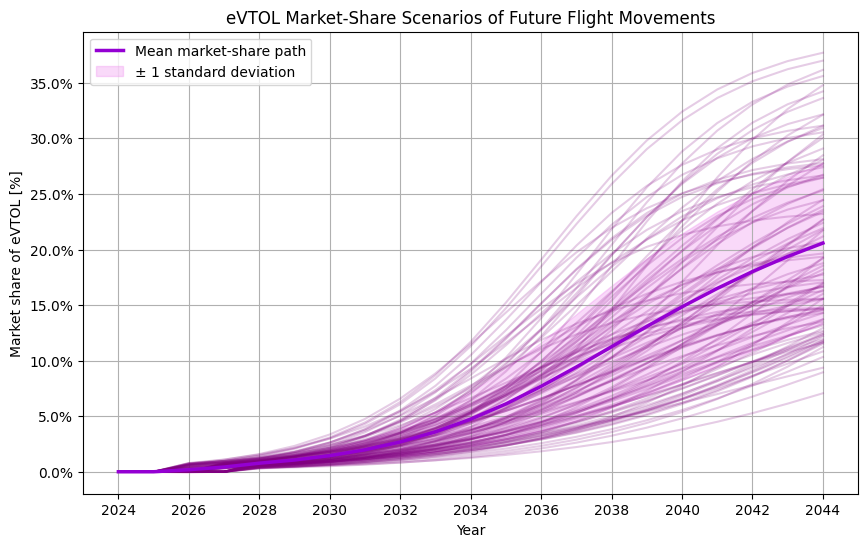

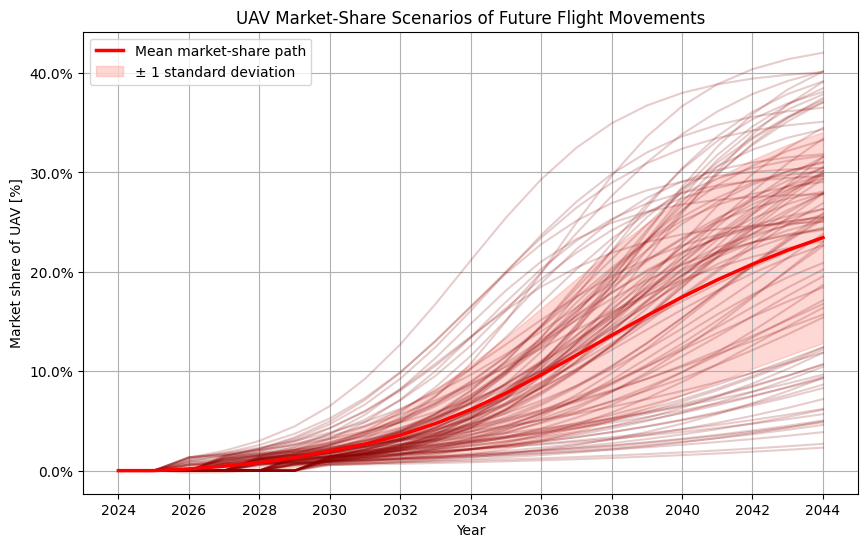

In [11]:
def plot_market_share_scenarios(
    future_years,
    scenario_paths,
    mean_path,
    std_path,
    path_color,
    mean_color,
    band_color,
    y_label,
    title,
):
    """Plot a subset of stochastic market-share paths and their summary statistics."""
    plt.figure(figsize=(10, 6))

    n_paths_to_plot = min(100, scenario_paths.shape[1])
    random_indices = np.random.choice(scenario_paths.shape[1], size=n_paths_to_plot, replace=False)
    for i in random_indices:
        plt.plot(future_years, scenario_paths[:, i], color=path_color, alpha=0.2)

    plt.plot(future_years, mean_path, color=mean_color, linewidth=2.5, label="Mean market-share path")
    plt.fill_between(
        future_years,
        mean_path - std_path,
        mean_path + std_path,
        color=band_color,
        alpha=0.3,
        label="± 1 standard deviation",
    )

    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.xlabel("Year")
    plt.ylabel(y_label)
    plt.title(title)
    plt.xticks(future_years[::2])
    plt.legend()
    plt.grid(True)
    plt.show()


plot_market_share_scenarios(
    future_years=future_years,
    scenario_paths=scenarios_evtol_flt_share,
    mean_path=mean_evtol_flt_share,
    std_path=std_evtol_flt_share,
    path_color="purple",
    mean_color="darkviolet",
    band_color="violet",
    y_label="Market share of eVTOL [%]",
    title="eVTOL Market-Share Scenarios of Future Flight Movements",
)

plot_market_share_scenarios(
    future_years=future_years,
    scenario_paths=scenarios_uav_share,
    mean_path=mean_uav_share,
    std_path=std_uav_share,
    path_color="darkred",
    mean_color="red",
    band_color="salmon",
    y_label="Market share of UAV [%]",
    title="UAV Market-Share Scenarios of Future Flight Movements",
)


### 4. Identification of Potential Real Options


#### 4.1 Real Options on the System

**1. Option to defer**  
AEROVALE could postpone the construction of dedicated eVTOL or UAV airside facilities until uncertainty regarding market adoption, regulation, and actual demand is reduced. This option is appropriate because both eVTOL and UAV operations are emerging use cases with uncertain timing and scale. Deferring investment reduces the risk of building infrastructure too early or at excessive size.

**2. Option to stage**  
AEROVALE could implement new airside infrastructure in phases. For example, the airport could first build a small vertiport and one UAV operations area, and later expand these facilities if traffic grows. This option is particularly suitable for airport infrastructure because it allows incremental investment while preserving the ability to respond to future growth.

#### 4.2 Real Options in the System

**1. Expandable vertiport design**  
AEROVALE could initially build a small vertiport but design it in such a way that additional landing pads, stands, and charging positions can be added later with limited disruption. This is a real option in the system because the flexibility is embedded directly into the physical design of the airport infrastructure. It would allow the airport to respond efficiently if eVTOL demand grows faster than expected.

**2. Multi-use UAV / general aviation operating area**  
AEROVALE could design part of the airside area as a modular operating zone that can initially serve general aviation or service vehicles and later be reconfigured for UAV launch, landing, and handling operations. This represents a real option in the system because the infrastructure is physically designed to support future functional adaptation. It reduces the risk of underutilized infrastructure in early years while preserving flexibility for later UAV growth.


### 5. Definition of a Candidate Flexibility

#### 5.1 Selected Candidate Flexibility

The selected candidate flexibility is the **expandable vertiport and UAV operations area**, combined with a **staged expansion strategy**. Initially, only a limited number of eVTOL landing pads and UAV operation zones are constructed. Additional capacity is added over time depending on observed demand.

#### 5.2 Underlying Real Options

This candidate flexibility is based on the combination of:
- **Option to stage (real option on the system):** Infrastructure is developed incrementally in phases rather than built at full capacity from the beginning.
- **Option to expand (real option in the system):** The initial infrastructure is designed in a modular way, allowing future extensions such as additional vertiport pads or UAV areas with relatively low cost and disruption.

#### 5.3 Operating Principle

The flexibility operates based on simple decision rules. At each point in time, the current demand for eVTOL and UAV operations is compared with the available infrastructure capacity:
- If demand approaches or exceeds capacity, additional infrastructure is constructed, for example new vertiport pads or UAV areas.
- If demand remains low, expansion is postponed.

#### 5.4 Expected Strategic Benefit

This approach allows the airport to:
- **Limit downside risk** by avoiding overinvestment in early stages when demand is uncertain.
- **Capture upside potential** by expanding infrastructure when demand materializes.


### 6. Definition of Revenue, Cost, and Valuation Framework


#### 6.1 System Definition and Capacity Variables

The airside system consists of two infrastructure components:
- **eVTOL infrastructure**: vertiport pads / stands for eVTOL operations
- **UAV infrastructure**: UAV operation pads / handling positions for drone operations

The relevant capacity variables are:
- $K_{t,e}$: available eVTOL pads in year $t$
- $K_{t,u}$: available UAV positions in year $t$
- $\Delta K_{t,e} = K_{t,e} - K_{t-1,e}$: eVTOL capacity expansion in year $t$
- $\Delta K_{t,u} = K_{t,u} - K_{t-1,u}$: UAV capacity expansion in year $t$

Each infrastructure unit provides a fixed number of annual movements, which leads to total movement capacity:
- $k_e$: annual eVTOL movements per pad
- $k_u$: annual UAV movements per position
- $\widetilde{K}_{t,e} = K_{t,e} \cdot k_e$: eVTOL movement capacity in year $t$
- $\widetilde{K}_{t,u} = K_{t,u} \cdot k_u$: UAV movement capacity in year $t$

Demand is represented by the scenario outputs from the previous tasks:
- $D_{t,e}$: eVTOL demand in year $t$
- $D_{t,u}$: UAV demand in year $t$

Since demand may exceed capacity, served demand is limited by available infrastructure:
- $Q_{t,e} = \min(D_{t,e}, \widetilde{K}_{t,e})$: eVTOL served demand in year $t$
- $Q_{t,u} = \min(D_{t,u}, \widetilde{K}_{t,u})$: UAV served demand in year $t$

#### 6.2 Revenue and Cost Functions

The airport generates revenues from the use of airside infrastructure:
- $R_{t,e} = Q_{t,e} \cdot r_e$: eVTOL revenue in year $t$ (landing, handling, and infrastructure usage fees)
- $R_{t,u} = Q_{t,u} \cdot r_u$: UAV revenue in year $t$ (access, handling, and operational service fees)


Total annual revenue:
- $R_t = R_{t,e} + R_{t,u} = \min(D_{t,e}, \widetilde{K}_{t,e}) \cdot r_e + \min(D_{t,u}, \widetilde{K}_{t,u}) \cdot r_u$

Only served demand generates revenue. Unmet demand is lost due to capacity constraints.

Total costs are divided into:
- **CAPEX** for construction and expansion
- **OPEX** for annual operation

Capital expenditures are incurred when capacity is expanded. Only positive changes are considered:
- $c_{capex,e}$: investment costs per new eVTOL unit
- $c_{capex,u}$: investment costs per new UAV unit
- $\alpha_e, \alpha_u \in (0,1]$: economies of scale factors (If $\alpha < 1$, larger expansions are relatively cheaper per unit)

Total annual CAPEX:
- $C_{CAPEX,t} = (\Delta K_{t,e})^{\alpha_e} \cdot c_{capex,e} + (\Delta K_{t,u})^{\alpha_u} \cdot c_{capex,u}$

Operational expenditure consists of fixed and variable components:
- $C_{OPEX,t,e} = K_{t,e} \cdot c_{fix,e} + Q_{t,e} \cdot c_{var,e}$: OPEX for eVTOL in year $t$
- $C_{OPEX,t,u} = K_{t,u} \cdot c_{fix,u} + Q_{t,u} \cdot c_{var,u}$: OPEX for UAV in year $t$

Total annual OPEX:
- $C_{OPEX,t} = C_{OPEX,t,e} + C_{OPEX,t,u}$

The fixed component depends on installed infrastructure, while the variable component depends on actual usage.

Total costs:
- $C_t = C_{CAPEX,0}$ for $t = 0$
- $C_t = C_{CAPEX,t} + C_{OPEX,t}$ for $t > 0$

Annual cash flow:
- $CF_t = R_t - C_t$

Initial investment occurs at $t = 0$.


#### 6.3 Parameterization and Reliability of the Estimates

The model requires:
- revenue parameters $r_e$ and $r_u$
- CAPEX parameters $c_{capex,e}$, $c_{capex,u}$, $\alpha_e$, and $\alpha_u$
- OPEX parameters $c_{fix,e}$, $c_{fix,u}$, $c_{var,e}$, and $c_{var,u}$
- capacity parameters $k_e$ and $k_u$
- financial parameter $\delta$

The assumptions are simplified but plausible for a scenario-based planning model:
- eVTOL infrastructure is more capital-intensive than UAV infrastructure
- eVTOL generates higher revenue per movement
- UAV systems have lower fixed and variable costs
- economies of scale are present in construction
- the discount rate reflects long-term infrastructure planning

The reliability of the numerical estimates is **moderate to low**, because eVTOL and UAV airport infrastructure is still emerging. The parameters should therefore be interpreted as scenario-based planning assumptions rather than precise forecasts.


### 7. ENPV of the Engineering System


#### 7.1 Build eVTOL and UAV Traffic Scenarios


The simulated market shares from Task 3 are converted into absolute annual movements. For each scenario, the future total flight movements from Task 2 are multiplied by the corresponding eVTOL and UAV shares. These movement scenarios are the demand inputs for all later revenue, cost, and ENPV calculations.

In [12]:
# Convert the stochastic market shares into absolute annual movements
scenarios_evtol_movements = np.round(scenarios_flt * scenarios_evtol_flt_share)
scenarios_uav_movements = np.round(scenarios_flt * scenarios_uav_share)

# Summarize the resulting demand inputs used in the valuation model
traffic_scenario_summary = pd.DataFrame(
    {
        "Metric": [
            "Scenario-matrix shape",
            "Mean demand in first planning year",
            "Mean demand in final planning year",
        ],
        "Conventional": [
            str(scenarios_flt.shape),
            round(np.mean(scenarios_flt[0]), 1),
            round(np.mean(scenarios_flt[-1]), 1),
        ],
        "eVTOL": [
            str(scenarios_evtol_movements.shape),
            round(np.mean(scenarios_evtol_movements[0]), 1),
            round(np.mean(scenarios_evtol_movements[-1]), 1),
        ],
        "UAV": [
            str(scenarios_uav_movements.shape),
            round(np.mean(scenarios_uav_movements[0]), 1),
            round(np.mean(scenarios_uav_movements[-1]), 1),
        ],
    }
)
traffic_scenario_summary


,Metric,Conventional,eVTOL,UAV
0,Scenario-matrix shape,"(21, 1000)","(21, 1000)","(21, 1000)"
1,Mean demand in first planning year,33500.0,0.0,0.0
2,Mean demand in final planning year,45750.1,9421.6,10740.7


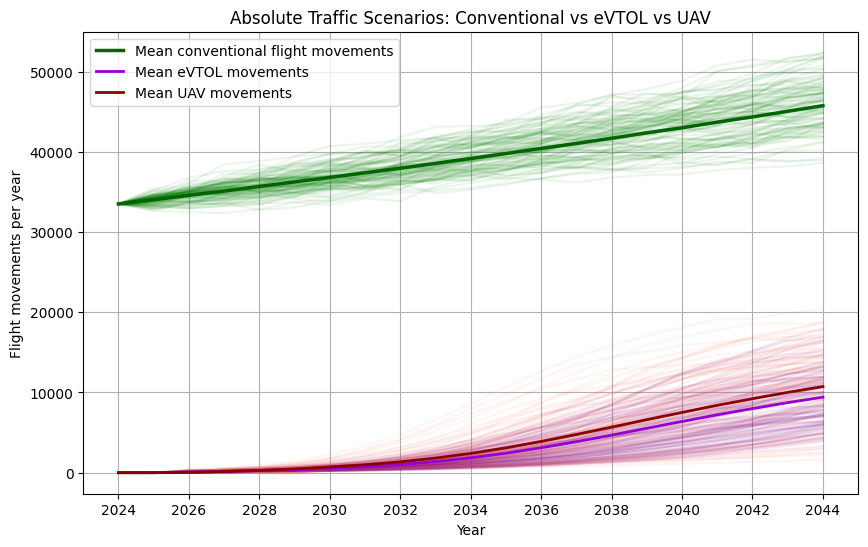

In [13]:
# Visualize a subset of traffic scenarios together with the mean demand paths
plt.figure(figsize=(10, 6))

n_paths_to_plot = min(100, n_scenarios)
selected_scenarios = np.random.choice(n_scenarios, size=n_paths_to_plot, replace=False)

for scenario_idx in selected_scenarios:
    plt.plot(future_years, scenarios_flt[:, scenario_idx], color="green", alpha=0.08)
    plt.plot(future_years, scenarios_evtol_movements[:, scenario_idx], color="purple", alpha=0.08)
    plt.plot(future_years, scenarios_uav_movements[:, scenario_idx], color="salmon", alpha=0.08)

plt.plot(
    future_years,
    np.mean(scenarios_flt, axis=1),
    color="darkgreen",
    linewidth=2.5,
    label="Mean conventional flight movements",
)
plt.plot(
    future_years,
    np.mean(scenarios_evtol_movements, axis=1),
    color="darkviolet",
    linewidth=2,
    label="Mean eVTOL movements",
)
plt.plot(
    future_years,
    np.mean(scenarios_uav_movements, axis=1),
    color="darkred",
    linewidth=2,
    label="Mean UAV movements",
)

plt.xlabel("Year")
plt.ylabel("Flight movements per year")
plt.title("Absolute Traffic Scenarios: Conventional vs eVTOL vs UAV")
plt.xticks(future_years[::2])
plt.legend()
plt.grid(True)
plt.show()


#### 7.2 Economic Assumptions and Financial Parameters


The ENPV model needs a compact set of assumptions for capacity, revenues, costs, and discounting. These parameter assumptions are used in the baseline calculations, the optimization search, and the sensitivity analysis.

In [14]:
# Base-case economic parameters for the airport-side business model
params = {
    # Annual movement capacity per infrastructure unit
    "k_e": 3650,       # annual eVTOL movements per pad
    "k_u": 7300,       # annual UAV movements per position

    # Revenues per served movement
    "r_e": 500,        # CHF per served eVTOL movement
    "r_u": 200,        # CHF per served UAV movement

    # CAPEX for new infrastructure units
    "c_capex_e": 600000,   # CHF per new eVTOL pad
    "c_capex_u": 120000,   # CHF per new UAV position
    "alpha_e": 0.90,       # economies-of-scale exponent for eVTOL expansions
    "alpha_u": 0.80,       # economies-of-scale exponent for UAV expansions

    # OPEX for installed infrastructure and served demand
    "c_fix_e": 150000,     # annual fixed OPEX per eVTOL pad
    "c_fix_u": 20000,      # annual fixed OPEX per UAV position
    "c_var_e": 100,        # variable OPEX per served eVTOL movement
    "c_var_u": 50,         # variable OPEX per served UAV movement

    # Financial parameter
    "delta": 0.05,         # discount rate
}


In [15]:
# Helper function for readable CHF output in printed summaries
def format_chf(value):
    """Format a number as CHF with Swiss thousands separators."""
    return f"CHF {value:,.2f}".replace(",", "'")


#### 7.3 Revenue and Cost Functions


The annual cashflow is computed using the following functions:

$$
R_t = r_e \cdot \min(D_{t,e}, K_{t,e} k_e) + r_u \cdot \min(D_{t,u}, K_{t,u} k_u)
$$

$$
CAPEX_t = c_{capex,e} \cdot (\Delta K_{t,e})^{\alpha_e} + c_{capex,u} \cdot (\Delta K_{t,u})^{\alpha_u}
$$

$$
OPEX_t = K_{t,e} c_{fix,e} + K_{t,u} c_{fix,u} + c_{var,e} \cdot \min(D_{t,e}, K_{t,e} k_e) + c_{var,u} \cdot \min(D_{t,u}, K_{t,u} k_u)
$$


In [16]:
# Annual revenue from served eVTOL and UAV demand
def revenue_t(D_e, D_u, K_e, K_u, p):
    """Return annual revenue for one year and one scenario."""
    K_tilde_e = K_e * p["k_e"]
    K_tilde_u = K_u * p["k_u"]

    served_e = min(D_e, K_tilde_e)
    served_u = min(D_u, K_tilde_u)

    return served_e * p["r_e"] + served_u * p["r_u"]


# Annual CAPEX for newly installed infrastructure units
def capex_t(delta_K_e, delta_K_u, p):
    """Return annual expansion CAPEX with economies of scale."""
    delta_K_e = max(delta_K_e, 0)
    delta_K_u = max(delta_K_u, 0)

    capex_e = (delta_K_e ** p["alpha_e"]) * p["c_capex_e"]
    capex_u = (delta_K_u ** p["alpha_u"]) * p["c_capex_u"]

    return capex_e + capex_u


# Annual OPEX for installed capacity and served demand
def opex_t(D_e, D_u, K_e, K_u, p):
    """Return annual operating expenditure for one year and one scenario."""
    K_tilde_e = K_e * p["k_e"]
    K_tilde_u = K_u * p["k_u"]

    served_e = min(D_e, K_tilde_e)
    served_u = min(D_u, K_tilde_u)

    fix_opex_e = K_e * p["c_fix_e"]
    fix_opex_u = K_u * p["c_fix_u"]
    var_opex_e = served_e * p["c_var_e"]
    var_opex_u = served_u * p["c_var_u"]

    return fix_opex_e + fix_opex_u + var_opex_e + var_opex_u


#### 7.4 Predefined Conventional Planning Approach


In the predefined conventional approach, the full capacity schedule is defined in advance. The airport commits to a deterministic number of eVTOL pads and UAV positions in each year, regardless of which demand scenario actually occurs.

##### 7.4.1 Predefined Capacity Schedule


The schedule below is the baseline conventional plan used as the first benchmark before searching for better solutions. Each entry gives the number of installed infrastructure units in one planning period.

In [17]:
# Predefined conventional schedules with fixed capacity decisions for the full horizon
predefined_K_e_schedule = [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2]
predefined_K_u_schedule = [0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3]


##### 7.4.2 NPV of One Scenario


For one demand scenario, the code steps through the planning horizon year by year, computes revenue, CAPEX, and OPEX, discounts the resulting net cash flow, and sums everything into one NPV.

In [18]:
# NPV of one scenario under a fully predefined conventional capacity schedule
def npv_conventional_one_scenario(demand_e_path, demand_u_path, K_e_schedule, K_u_schedule, p):
    """Compute the NPV of one scenario for the conventional planning approach."""
    T = len(K_e_schedule) - 1
    npv = 0.0

    for t in range(T + 1):
        K_e = K_e_schedule[t]
        K_u = K_u_schedule[t]
        D_e = demand_e_path[t]
        D_u = demand_u_path[t]

        if t == 0:
            delta_K_e = K_e
            delta_K_u = K_u
        else:
            delta_K_e = K_e_schedule[t] - K_e_schedule[t - 1]
            delta_K_u = K_u_schedule[t] - K_u_schedule[t - 1]

        CAPEX_t = capex_t(delta_K_e, delta_K_u, p)

        if t == 0:
            npv -= CAPEX_t
        else:
            R_t = revenue_t(D_e, D_u, K_e, K_u, p)
            OPEX_t = opex_t(D_e, D_u, K_e, K_u, p)
            npv += (R_t - CAPEX_t - OPEX_t) / ((1 + p["delta"]) ** t)

    return npv


##### 7.4.3 ENPV Across All Scenarios


The ENPV is the arithmetic mean of the scenario-specific NPVs:

$$
ENPV = \frac{1}{N} \sum_{s=1}^{N} NPV_s
$$

This gives one expected value for the predifined conventional plan over the full scenario set.


In [19]:
# ENPV of the predefined conventional planning approach across all simulated scenarios
def enpv_conventional(scenarios_evtol_movements, scenarios_uav_movements, K_e_schedule, K_u_schedule, p):
    """Compute the ENPV and the full NPV distribution for the conventional plan."""
    n_scenarios = scenarios_evtol_movements.shape[1]
    npvs = np.zeros(n_scenarios)

    for s in range(n_scenarios):
        demand_e_path = scenarios_evtol_movements[:, s]
        demand_u_path = scenarios_uav_movements[:, s]
        npvs[s] = npv_conventional_one_scenario(
            demand_e_path,
            demand_u_path,
            K_e_schedule,
            K_u_schedule,
            p,
        )

    return np.mean(npvs), npvs


enpv_conv, npvs_conv = enpv_conventional(
    scenarios_evtol_movements,
    scenarios_uav_movements,
    predefined_K_e_schedule,
    predefined_K_u_schedule,
    params,
)

predefined_conventional_summary = pd.DataFrame(
    {
        "Conventional Planning": ["ENPV", "Minimum NPV", "Maximum NPV"],
        "Value": [
            format_chf(enpv_conv),
            format_chf(np.min(npvs_conv)),
            format_chf(np.max(npvs_conv)),
        ],
    }
)
predefined_conventional_summary


,Conventional Planning,Value
0,ENPV,CHF 12'412'266.46
1,Minimum NPV,CHF 1'351'626.47
2,Maximum NPV,CHF 26'368'386.51


#### 7.5 Predefined Flexible Planning Approach


In the predefined flexible approach, only the initial capacity and a simple decision rule are fixed in advance. The actual expansion decision depends on the realized demand path, so capacity can react to uncertainty during the planning horizon.

##### 7.5.1 Initial Capacity and Decision Rule


The flexible rule uses two parameters for each infrastructure type: 
- trigger threshold $\theta_1$ 
- expansion size $\theta_2$

If remaining annual movement capacity falls below $\theta_1$, an expansion of size $\theta_2$ is decided. The new capacity becomes available one year later.

In [20]:
# Baseline flexible policy: initial capacities and simple expansion rules
flex_params = {
    "K0_e": 0,        # initial eVTOL pads
    "K0_u": 0,        # initial UAV positions
    "theta1_e": 0,    # eVTOL trigger threshold in annual movements
    "theta2_e": 1,    # eVTOL expansion size in pads
    "theta1_u": 100,  # UAV trigger threshold in annual movements
    "theta2_u": 1,    # UAV expansion size in positions
}


#### 7.8 Best Flexible Solution

##### 7.8.1 Search and Best Result

The flexible planning approach varies the following parameters:
- initial capacities $K_{0,e}$ and $K_{0,u}$
- decision-rule parameter for the trigger threshold $\theta_1$
- decision-rule parameter for the expansion size $\theta_2$

The interpretation of $\theta_1$ is:
- $\theta_1 < 0$: delayed expansion, because a temporary capacity shortfall is accepted before expansion is triggered
- $\theta_1 = 0$: just-in-time expansion, because expansion is triggered exactly when demand reaches available capacity
- $\theta_1 > 0$: proactive expansion, because expansion is triggered while spare capacity is still available

Each candidate policy is evaluated over the full scenario set, and the ENPV is used as the selection criterion. The code below stores the ENPV-maximizing flexible approach in `best_flex_params`.


For one demand scenario, the code steps through the planning horizon year by year, computes revenue, CAPEX, and OPEX, discounts the resulting net cash flow, and sums everything into one NPV.

In [21]:
# NPV of one scenario under a flexible expansion rule
def npv_flexible_one_scenario(demand_e_path, demand_u_path, flex, p):
    """Compute the NPV of one scenario for the flexible planning approach."""
    T = len(demand_e_path) - 1

    K_e_path = np.zeros(T + 1)
    K_u_path = np.zeros(T + 1)
    K_e_path[0] = flex["K0_e"]
    K_u_path[0] = flex["K0_u"]

    npv = 0.0

    for t in range(T + 1):
        K_e = K_e_path[t]
        K_u = K_u_path[t]
        D_e = demand_e_path[t]
        D_u = demand_u_path[t]
        R_t = revenue_t(D_e, D_u, K_e, K_u, p)

        if t == 0:
            CAPEX_t = capex_t(K_e, K_u, p)
            npv -= CAPEX_t
        else:
            delta_K_e = 0
            delta_K_u = 0

            if t < T:
                remaining_e = K_e * p["k_e"] - D_e
                remaining_u = K_u * p["k_u"] - D_u

                if remaining_e < flex["theta1_e"]:
                    delta_K_e = flex["theta2_e"]

                if remaining_u < flex["theta1_u"]:
                    delta_K_u = flex["theta2_u"]

                K_e_path[t + 1] = K_e + delta_K_e
                K_u_path[t + 1] = K_u + delta_K_u

            OPEX_t = opex_t(D_e, D_u, K_e, K_u, p)
            CAPEX_t = capex_t(delta_K_e, delta_K_u, p)
            npv += (R_t - OPEX_t - CAPEX_t) / ((1 + p["delta"]) ** t)

    return npv, K_e_path, K_u_path


##### 7.5.3 ENPV Across All Scenarios


The ENPV is the arithmetic mean of the scenario-specific NPVs:

$$
ENPV = \frac{1}{N} \sum_{s=1}^{N} NPV_s
$$

This gives one expected value for the predefined flexible plan over the full scenario set.

In [22]:
# ENPV of the predefined flexible planning approach across all simulated scenarios
def enpv_flexible(scenarios_evtol_movements, scenarios_uav_movements, flex, p):
    """Compute the ENPV and the NPV distribution for one flexible policy."""
    n_scenarios = scenarios_evtol_movements.shape[1]
    npvs = np.zeros(n_scenarios)

    for s in range(n_scenarios):
        demand_e_path = scenarios_evtol_movements[:, s]
        demand_u_path = scenarios_uav_movements[:, s]
        npvs[s], _, _ = npv_flexible_one_scenario(
            demand_e_path,
            demand_u_path,
            flex,
            p,
        )

    return np.mean(npvs), npvs


enpv_flex, npvs_flex = enpv_flexible(
    scenarios_evtol_movements,
    scenarios_uav_movements,
    flex_params,
    params,
)

predefined_flexible_summary = pd.DataFrame(
    {
        "Flexible Planning": ["ENPV", "Minimum NPV", "Maximum NPV"],
        "Value": [
            format_chf(enpv_flex),
            format_chf(np.min(npvs_flex)),
            format_chf(np.max(npvs_flex)),
        ],
    }
)
predefined_flexible_summary


,Flexible Planning,Value
0,ENPV,CHF 14'110'672.35
1,Minimum NPV,CHF 3'015'796.88
2,Maximum NPV,CHF 34'462'759.66


#### 7.6 Influence of Initial Capacity on ENPV


This section varies the initial capacity and calculates the resulting ENPV for the conventional and flexible planning approaches.

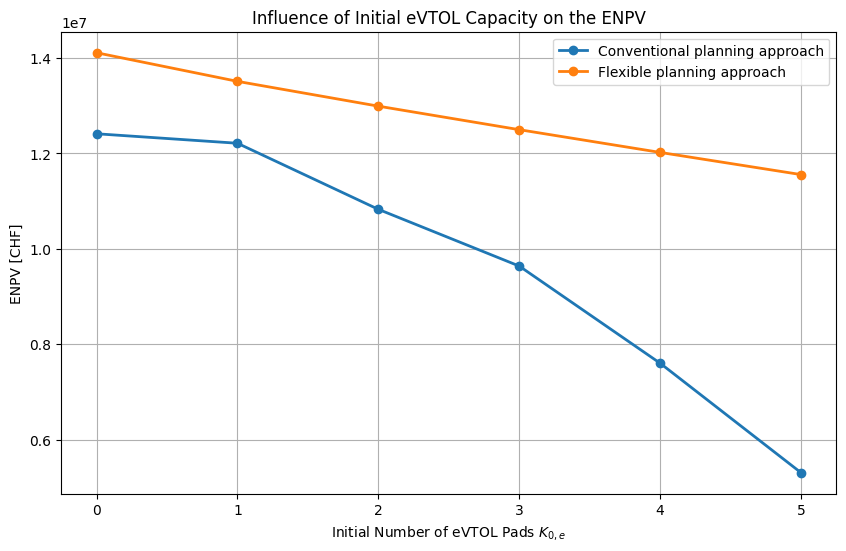

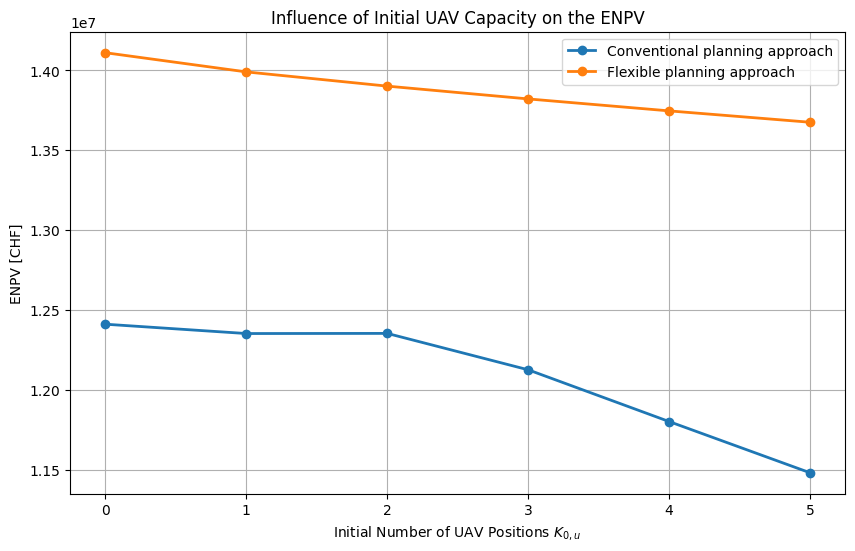

In [23]:
# Influence of the initial capacity on ENPV for the predefined conventional and flexible approaches
initial_capacity_grid = [0, 1, 2, 3, 4, 5]

enpv_conv_K0_e = []
enpv_flex_K0_e = []
enpv_conv_K0_u = []
enpv_flex_K0_u = []

# Vary the initial eVTOL capacity for the predefined conventional and flexible approaches
for K0_e in initial_capacity_grid:
    K_e_schedule_test = np.array(predefined_K_e_schedule, dtype=int).copy()
    K_u_schedule_test = np.array(predefined_K_u_schedule, dtype=int).copy()
    K_e_schedule_test[0] = K0_e
    K_e_schedule_test = np.maximum.accumulate(K_e_schedule_test)

    enpv_conv_test, _ = enpv_conventional(
        scenarios_evtol_movements,
        scenarios_uav_movements,
        K_e_schedule_test,
        K_u_schedule_test,
        params,
    )
    enpv_conv_K0_e.append(enpv_conv_test)

    flex_test = flex_params.copy()
    flex_test["K0_e"] = K0_e
    enpv_flex_test, _ = enpv_flexible(
        scenarios_evtol_movements,
        scenarios_uav_movements,
        flex_test,
        params,
    )
    enpv_flex_K0_e.append(enpv_flex_test)

# Vary the initial UAV capacity for the predefined conventional and flexible approaches
for K0_u in initial_capacity_grid:
    K_e_schedule_test = np.array(predefined_K_e_schedule, dtype=int).copy()
    K_u_schedule_test = np.array(predefined_K_u_schedule, dtype=int).copy()
    K_u_schedule_test[0] = K0_u
    K_u_schedule_test = np.maximum.accumulate(K_u_schedule_test)

    enpv_conv_test, _ = enpv_conventional(
        scenarios_evtol_movements,
        scenarios_uav_movements,
        K_e_schedule_test,
        K_u_schedule_test,
        params,
    )
    enpv_conv_K0_u.append(enpv_conv_test)

    flex_test = flex_params.copy()
    flex_test["K0_u"] = K0_u
    enpv_flex_test, _ = enpv_flexible(
        scenarios_evtol_movements,
        scenarios_uav_movements,
        flex_test,
        params,
    )
    enpv_flex_K0_u.append(enpv_flex_test)

enpv_conv_K0_e = np.array(enpv_conv_K0_e)
enpv_flex_K0_e = np.array(enpv_flex_K0_e)
enpv_conv_K0_u = np.array(enpv_conv_K0_u)
enpv_flex_K0_u = np.array(enpv_flex_K0_u)

# Plot 1: influence of K0_e
plt.figure(figsize=(10, 6))
plt.plot(initial_capacity_grid, enpv_conv_K0_e, marker="o", linewidth=2, label="Conventional planning approach")
plt.plot(initial_capacity_grid, enpv_flex_K0_e, marker="o", linewidth=2, label="Flexible planning approach")
plt.xlabel(r"Initial Number of eVTOL Pads $K_{0,e}$")
plt.ylabel("ENPV [CHF]")
plt.title("Influence of Initial eVTOL Capacity on the ENPV")
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: influence of K0_u
plt.figure(figsize=(10, 6))
plt.plot(initial_capacity_grid, enpv_conv_K0_u, marker="o", linewidth=2, label="Conventional planning approach")
plt.plot(initial_capacity_grid, enpv_flex_K0_u, marker="o", linewidth=2, label="Flexible planning approach")
plt.xlabel(r"Initial Number of UAV Positions $K_{0,u}$")
plt.ylabel("ENPV [CHF]")
plt.title("Influence of Initial UAV Capacity on the ENPV")
plt.grid(True)
plt.legend()
plt.show()


#### 7.7 Best Conventional Solution


##### 7.7.1 Search and Best Result


The conventional planning approach describes a plan by three design choices for each infrastructure type: 
- initial capacity $K_0$
- timing of one capacity adjustment $t_{\Delta K}$
- adjustment size $\Delta K$

The code below evaluates every candidate combination with `itertools.product`, computes its ENPV, and stores the ENPV-maximizing candidate in `best_solution`. The resulting schedules are `best_conv_K_e` and `best_conv_K_u`.

In [24]:
# Search the best conventional plan on a simple grid of initial capacities and one later adjustment

def build_conventional_schedule(K0, t_deltaK, delta_K, horizon_years):
    """Return a conventional schedule with one deterministic expansion from t_deltaK onward."""
    schedule = np.full(horizon_years + 1, K0, dtype=int)
    schedule[t_deltaK:] = K0 + delta_K
    return schedule


# Candidate values of the conventional design variables
K0_e_values = [0, 1]            # possible initial capacity for eVTOL pads 
K0_u_values = [0, 1]            # possible initial capacity UAV positions
t_deltaK_e_values = [12, 13]    # possible years for one capacity adjustment of eVTOL pads
t_deltaK_u_values = [11, 12]    # possible years for one capacity adjustment of UAV positions
delta_K_e_values = [1, 2, 3]    # possible adjustment size of eVTOL pads
delta_K_u_values = [0, 1, 2]    # possible adjustment size of UAV positions

best_enpv = -np.inf
best_solution = None

for K0_e, K0_u, t_deltaK_e, t_deltaK_u, delta_K_e, delta_K_u in product(
    K0_e_values,
    K0_u_values,
    t_deltaK_e_values,
    t_deltaK_u_values,
    delta_K_e_values,
    delta_K_u_values,
):
    candidate_K_e_schedule = build_conventional_schedule(K0_e, t_deltaK_e, delta_K_e, horizon_years)
    candidate_K_u_schedule = build_conventional_schedule(K0_u, t_deltaK_u, delta_K_u, horizon_years)

    enpv_candidate, _ = enpv_conventional(
        scenarios_evtol_movements,
        scenarios_uav_movements,
        candidate_K_e_schedule,
        candidate_K_u_schedule,
        params,
    )

    if enpv_candidate > best_enpv:
        best_enpv = enpv_candidate
        best_solution = {
            "K0_e": K0_e,
            "K0_u": K0_u,
            "t_deltaK_e": t_deltaK_e,
            "t_deltaK_u": t_deltaK_u,
            "delta_K_e": delta_K_e,
            "delta_K_u": delta_K_u,
            "K_e_schedule": candidate_K_e_schedule.copy(),
            "K_u_schedule": candidate_K_u_schedule.copy(),
        }

best_conv_K_e = best_solution["K_e_schedule"]
best_conv_K_u = best_solution["K_u_schedule"]

best_conventional_summary = pd.DataFrame(
    {
        "Best Conventional Approach": ["ENPV", "K0_e", "K0_u", "t_deltaK_e", "t_deltaK_u", "delta_K_e", "delta_K_u"],
        "Value": [
            format_chf(best_enpv),
            best_solution["K0_e"],
            best_solution["K0_u"],
            best_solution["t_deltaK_e"],
            best_solution["t_deltaK_u"],
            best_solution["delta_K_e"],
            best_solution["delta_K_u"],
        ],
    }
)

print("Best conventional eVTOL schedule:")
print(best_conv_K_e)
print()
print("Best conventional UAV schedule:")
print(best_conv_K_u)
print()
best_conventional_summary


Best conventional eVTOL schedule:
[1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3 3 3 3]

Best conventional UAV schedule:
[1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2]



,Best Conventional Approach,Value
0,ENPV,CHF 12'697'138.22
1,K0_e,1
2,K0_u,1
3,t_deltaK_e,13
4,t_deltaK_u,12
5,delta_K_e,2
6,delta_K_u,1


##### 7.7.2 Sensitivity Analysis of the Conventional Solution


This sensitivity analysis keeps one infrastructure schedule fixed at its optimized conventional value and varies the timing $t_{\Delta K}$ and the adjustment size $\Delta K$ of the other one. The plots show how strongly ENPV depends on when the deterministic expansion is made and how large it is.

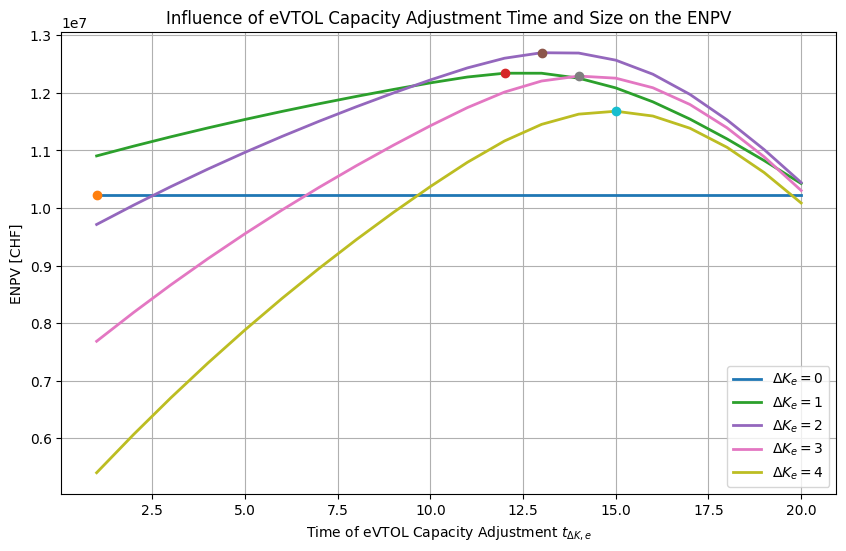

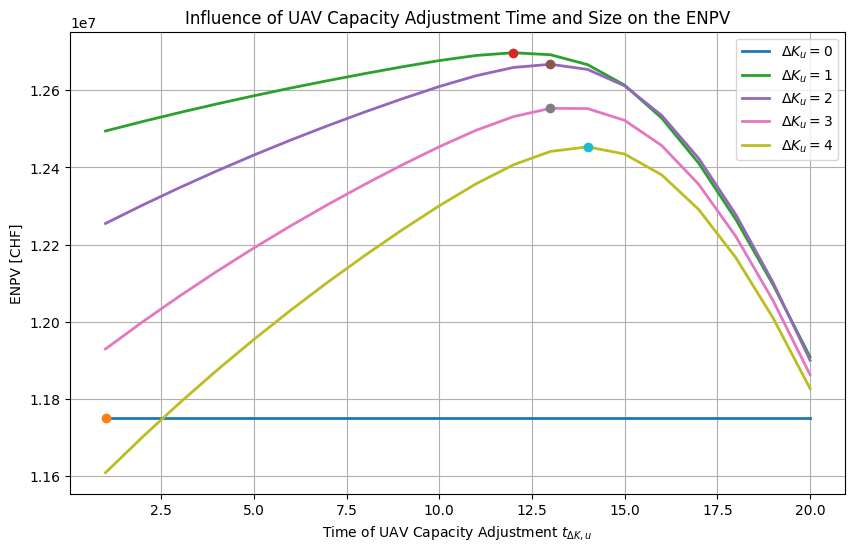

In [25]:
# Sensitivity of the best conventional plan to the timing and size of the single adjustment
adjustment_timing_grid = np.arange(1, horizon_years + 1)
delta_K_plot_values = [0, 1, 2, 3, 4]

best_K0_e = best_solution["K0_e"]
best_K0_u = best_solution["K0_u"]

enpv_conv_timing_e = {}
enpv_conv_timing_u = {}

# eVTOL sensitivity: vary only eVTOL timing and size, keep the UAV schedule fixed
for delta_K_e in delta_K_plot_values:
    enpv_list = []

    for t_deltaK_e in adjustment_timing_grid:
        K_e_schedule_test = build_conventional_schedule(best_K0_e, t_deltaK_e, delta_K_e, horizon_years)
        K_u_schedule_test = np.array(best_conv_K_u, dtype=int).copy()

        enpv_test, _ = enpv_conventional(
            scenarios_evtol_movements,
            scenarios_uav_movements,
            K_e_schedule_test,
            K_u_schedule_test,
            params,
        )
        enpv_list.append(enpv_test)

    enpv_conv_timing_e[delta_K_e] = np.array(enpv_list)

# UAV sensitivity: vary only UAV timing and size, keep the eVTOL schedule fixed
for delta_K_u in delta_K_plot_values:
    enpv_list = []

    for t_deltaK_u in adjustment_timing_grid:
        K_e_schedule_test = np.array(best_conv_K_e, dtype=int).copy()
        K_u_schedule_test = build_conventional_schedule(best_K0_u, t_deltaK_u, delta_K_u, horizon_years)

        enpv_test, _ = enpv_conventional(
            scenarios_evtol_movements,
            scenarios_uav_movements,
            K_e_schedule_test,
            K_u_schedule_test,
            params,
        )
        enpv_list.append(enpv_test)

    enpv_conv_timing_u[delta_K_u] = np.array(enpv_list)

# Plot 1: eVTOL
plt.figure(figsize=(10, 6))

for delta_K_e in delta_K_plot_values:
    y = enpv_conv_timing_e[delta_K_e]
    plt.plot(
        adjustment_timing_grid,
        y,
        linewidth=2,
        label=fr"$\Delta K_{{e}} = {delta_K_e}$",
    )

    idx_max = np.argmax(y)
    plt.plot(adjustment_timing_grid[idx_max], y[idx_max], "o")

plt.xlabel(r"Time of eVTOL Capacity Adjustment $t_{\Delta K,e}$")
plt.ylabel("ENPV [CHF]")
plt.title("Influence of eVTOL Capacity Adjustment Time and Size on the ENPV")
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: UAV
plt.figure(figsize=(10, 6))

for delta_K_u in delta_K_plot_values:
    y = enpv_conv_timing_u[delta_K_u]
    plt.plot(
        adjustment_timing_grid,
        y,
        linewidth=2,
        label=fr"$\Delta K_{{u}} = {delta_K_u}$",
    )

    idx_max = np.argmax(y)
    plt.plot(adjustment_timing_grid[idx_max], y[idx_max], "o")

plt.xlabel(r"Time of UAV Capacity Adjustment $t_{\Delta K,u}$")
plt.ylabel("ENPV [CHF]")
plt.title("Influence of UAV Capacity Adjustment Time and Size on the ENPV")
plt.grid(True)
plt.legend()
plt.show()


##### 7.7.3 Diagnose the Best Conventional Approach on the Mean Demand Path


The best conventional solution is applied to the mean demand path. It provides a deterministic interpretation of the optimized conventional schedule and shows the corresponding NPV on the average scenario.

In [26]:
# Diagnose the best conventional solution on the mean demand path
mean_demand_e_path = np.mean(scenarios_evtol_movements, axis=1)
mean_demand_u_path = np.mean(scenarios_uav_movements, axis=1)

npv_mean_conv = npv_conventional_one_scenario(
    mean_demand_e_path,
    mean_demand_u_path,
    best_conv_K_e,
    best_conv_K_u,
    params,
)

best_conventional_mean_path_summary = pd.DataFrame(
    {
        "Metric": [
            "NPV on mean demand path",
            "Initial eVTOL pads",
            "Final eVTOL pads",
            "Initial UAV positions",
            "Final UAV positions",
        ],
        "Value": [
            format_chf(npv_mean_conv),
            int(best_conv_K_e[0]),
            int(best_conv_K_e[-1]),
            int(best_conv_K_u[0]),
            int(best_conv_K_u[-1]),
        ],
    }
)

best_conventional_mean_path_capacity_paths = pd.DataFrame(
    {
        "Planning period": np.arange(horizon_years + 1),
        "Mean eVTOL demand": mean_demand_e_path,
        "Available eVTOL pads": best_conv_K_e,
        "Mean UAV demand": mean_demand_u_path,
        "Available UAV positions": best_conv_K_u,
    }
)

print(best_conventional_mean_path_capacity_paths.to_string(index=False))


 Planning period  Mean eVTOL demand  Available eVTOL pads  Mean UAV demand  Available UAV positions
               0              0.000                     1            0.000                        1
               1              0.000                     1            0.000                        1
               2             62.604                     1           59.505                        1
               3            148.327                     1          155.985                        1
               4            274.793                     1          287.984                        1
               5            383.151                     1          469.258                        1
               6            533.233                     1          721.619                        1
               7            739.362                     1          991.802                        1
               8           1016.897                     1         1352.880                        1


#### 7.8 Best Flexible Solution


##### 7.8.1 Search and Best Result


The flexible planning apporach varies the following parameter:
- initial capacities $K_{0,e}$ and $K_{0,u}$ 
- decision-rule parameter for the trigger threashold  
    - $\theta_1$ < 0: delayed expansion
    - $\theta_1$ = 0: just-in-time expansion
    - $\theta_1$ > 0: proactive expansion
- decision-rule parameter for the expansion size  $\theta_2$

Each candidate policy is evaluated over the full scenario set, and the ENPV is used as the selection criterion. The code below stores the ENPV-maximizing flexible approach in `best_flex_params`.

In [27]:
# Search the best flexible policy on a grid of initial capacities and decision-rule parameters
K0_e_values = [0, 1]            # possible initial capacity for eVTOL pads 
K0_u_values = [0, 1]            # possible initial capacity for UAV positions 

theta1_e_values = [-5, 0, 5]    # possible values for trigger threshold of annual eVTOL movements
theta2_e_values = [1, 2, 3]     # possible values for expansion size of eVTOL pads
theta1_u_values = [-5, 0, 5]    # possible values for trigger threshold of annual UAV movements
theta2_u_values = [1, 2, 3]     # possible values for expansion size of UAV positions

best_enpv_flex = -np.inf
best_flex_params = None
best_npvs_flex = None
search_results_flex = []

for K0_e, K0_u, theta1_e, theta2_e, theta1_u, theta2_u in product(
    K0_e_values,
    K0_u_values,
    theta1_e_values,
    theta2_e_values,
    theta1_u_values,
    theta2_u_values,
):
    flex_candidate = {
        "K0_e": K0_e,
        "K0_u": K0_u,
        "theta1_e": theta1_e,
        "theta2_e": theta2_e,
        "theta1_u": theta1_u,
        "theta2_u": theta2_u,
    }

    enpv_flex_candidate, npvs_flex_candidate = enpv_flexible(
        scenarios_evtol_movements,
        scenarios_uav_movements,
        flex_candidate,
        params,
    )

    search_results_flex.append(
        {
            "K0_e": K0_e,
            "K0_u": K0_u,
            "theta1_e": theta1_e,
            "theta2_e": theta2_e,
            "theta1_u": theta1_u,
            "theta2_u": theta2_u,
            "ENPV": enpv_flex_candidate,
        }
    )

    if enpv_flex_candidate > best_enpv_flex:
        best_enpv_flex = enpv_flex_candidate
        best_flex_params = flex_candidate.copy()
        best_npvs_flex = npvs_flex_candidate.copy()

search_results_flex_df = pd.DataFrame(search_results_flex).sort_values("ENPV", ascending=False).reset_index(drop=True)

best_flexible_summary = pd.DataFrame(
    {
        "Best Flexible Approach": ["ENPV", "K0_e", "K0_u", "theta1_e", "theta2_e", "theta1_u", "theta2_u"],
        "Value": [
            format_chf(best_enpv_flex),
            best_flex_params["K0_e"],
            best_flex_params["K0_u"],
            best_flex_params["theta1_e"],
            best_flex_params["theta2_e"],
            best_flex_params["theta1_u"],
            best_flex_params["theta2_u"],
        ],
    }
)

best_flexible_summary


,Best Flexible Approach,Value
0,ENPV,CHF 14'129'901.66
1,K0_e,0
2,K0_u,0
3,theta1_e,0
4,theta2_e,1
5,theta1_u,0
6,theta2_u,1


##### 7.8.2 Sensitivity of the Flexible Solution


This sensitivity focuses on the flexible rule itself. For each infrastructure type, the trigger threshold $\theta_1$ is varied over a wide range, and the resulting ENPV curves are shown for several expansion sizes $\theta_2$.

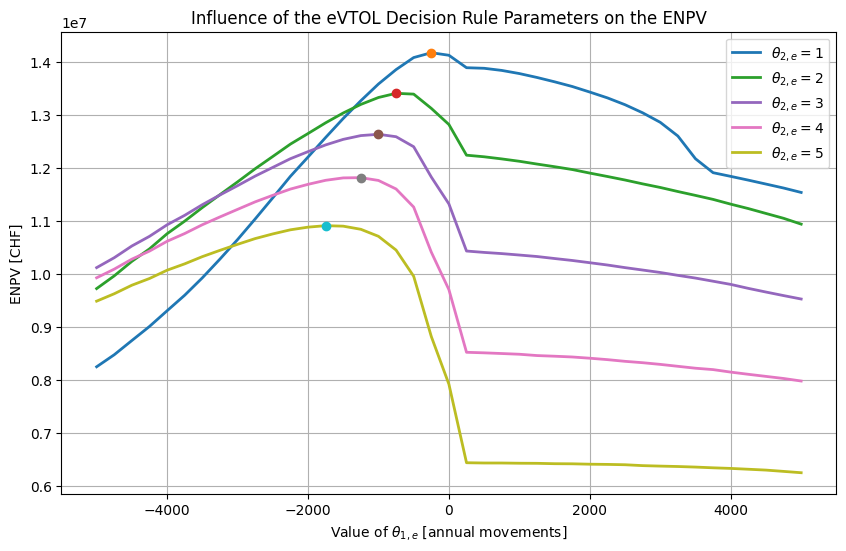

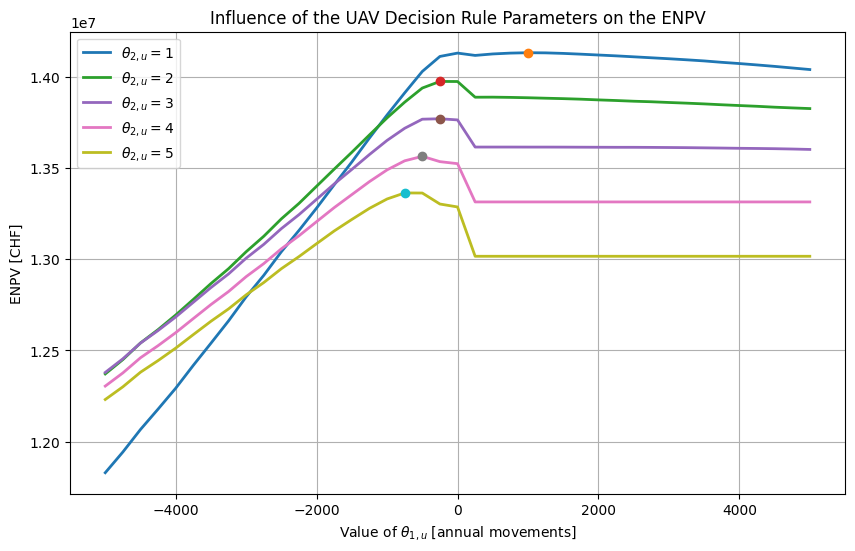

In [28]:
# Sensitivity of the best flexible policy to the decision-rule parameters theta1 and theta2
K0_e_opt = best_flex_params["K0_e"]
K0_u_opt = best_flex_params["K0_u"]

theta1_e_grid = np.arange(-5000, 5001, 250)
theta2_e_values = [1, 2, 3, 4, 5]
theta1_u_grid = np.arange(-5000, 5001, 250)
theta2_u_values = [1, 2, 3, 4, 5]

enpv_theta_e = {}
enpv_theta_u = {}

# eVTOL sensitivity: vary theta1_e and theta2_e, keep the UAV rule fixed
for theta2_e in theta2_e_values:
    enpv_list = []

    for theta1_e in theta1_e_grid:
        flex_test = best_flex_params.copy()
        flex_test["K0_e"] = K0_e_opt
        flex_test["K0_u"] = K0_u_opt
        flex_test["theta1_e"] = theta1_e
        flex_test["theta2_e"] = theta2_e

        enpv_test, _ = enpv_flexible(
            scenarios_evtol_movements,
            scenarios_uav_movements,
            flex_test,
            params,
        )
        enpv_list.append(enpv_test)

    enpv_theta_e[theta2_e] = np.array(enpv_list)

# UAV sensitivity: vary theta1_u and theta2_u, keep the eVTOL rule fixed
for theta2_u in theta2_u_values:
    enpv_list = []

    for theta1_u in theta1_u_grid:
        flex_test = best_flex_params.copy()
        flex_test["K0_e"] = K0_e_opt
        flex_test["K0_u"] = K0_u_opt
        flex_test["theta1_u"] = theta1_u
        flex_test["theta2_u"] = theta2_u

        enpv_test, _ = enpv_flexible(
            scenarios_evtol_movements,
            scenarios_uav_movements,
            flex_test,
            params,
        )
        enpv_list.append(enpv_test)

    enpv_theta_u[theta2_u] = np.array(enpv_list)

# Plot 1: eVTOL
plt.figure(figsize=(10, 6))

for theta2_e in theta2_e_values:
    y = enpv_theta_e[theta2_e]
    plt.plot(theta1_e_grid, y, linewidth=2, label=fr"$\theta_{{2,e}} = {theta2_e}$")
    idx_max = np.argmax(y)
    plt.plot(theta1_e_grid[idx_max], y[idx_max], "o")

plt.xlabel(r"Value of $\theta_{1,e}$ [annual movements]")
plt.ylabel("ENPV [CHF]")
plt.title("Influence of the eVTOL Decision Rule Parameters on the ENPV")
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: UAV
plt.figure(figsize=(10, 6))

for theta2_u in theta2_u_values:
    y = enpv_theta_u[theta2_u]
    plt.plot(theta1_u_grid, y, linewidth=2, label=fr"$\theta_{{2,u}} = {theta2_u}$")
    idx_max = np.argmax(y)
    plt.plot(theta1_u_grid[idx_max], y[idx_max], "o")

plt.xlabel(r"Value of $\theta_{1,u}$ [annual movements]")
plt.ylabel("ENPV [CHF]")
plt.title("Influence of the UAV Decision Rule Parameters on the ENPV")
plt.grid(True)
plt.legend()
plt.show()


##### 7.8.3 Diagnose the Best Flexible Approach on the Mean Demand Path


The best flexible approach is applied to the mean demand path. This is useful for interpretation, because it shows in a deterministic way when the rule would trigger additional capacity and what NPV it produces on the average scenario.

In [29]:
# Diagnose the best flexible policy on the mean demand path
mean_demand_e_path = np.mean(scenarios_evtol_movements, axis=1)
mean_demand_u_path = np.mean(scenarios_uav_movements, axis=1)

npv_mean, K_e_path_best, K_u_path_best = npv_flexible_one_scenario(
    mean_demand_e_path,
    mean_demand_u_path,
    best_flex_params,
    params,
)

best_flexible_mean_path_summary = pd.DataFrame(
    {
        "Metric": [
            "NPV on mean demand path",
            "Initial eVTOL pads",
            "Final eVTOL pads",
            "Initial UAV positions",
            "Final UAV positions",
        ],
        "Value": [
            format_chf(npv_mean),
            int(K_e_path_best[0]),
            int(K_e_path_best[-1]),
            int(K_u_path_best[0]),
            int(K_u_path_best[-1]),
        ],
    }
)

best_flexible_mean_path_capacity_paths = pd.DataFrame(
    {
        "Planning period": np.arange(horizon_years + 1),
        "Mean eVTOL demand": mean_demand_e_path,
        "Available eVTOL pads": K_e_path_best,
        "Mean UAV demand": mean_demand_u_path,
        "Available UAV positions": K_u_path_best,
    }
)

print(best_flexible_mean_path_capacity_paths.to_string(index=False))


 Planning period  Mean eVTOL demand  Available eVTOL pads  Mean UAV demand  Available UAV positions
               0              0.000                   0.0            0.000                      0.0
               1              0.000                   0.0            0.000                      0.0
               2             62.604                   0.0           59.505                      0.0
               3            148.327                   1.0          155.985                      1.0
               4            274.793                   1.0          287.984                      1.0
               5            383.151                   1.0          469.258                      1.0
               6            533.233                   1.0          721.619                      1.0
               7            739.362                   1.0          991.802                      1.0
               8           1016.897                   1.0         1352.880                      1.0


### 8. Comparison of Conventional and Flexible Solutions


#### 8.1 Comparison of the Predefined Approaches


The first comparison uses the predefined conventional and flexible approaches from Sections 7.4 and 7.5. The aim is to show how the two baseline planning logics differ before optimization.


##### 8.1.1 Capacity Paths on the Mean Demand Path


The plots visualize how the predifined schedules of the conventional planning approach and the predefined decision rules of the flexible approach are applied on the mean demand for both eVTOL and UAV.

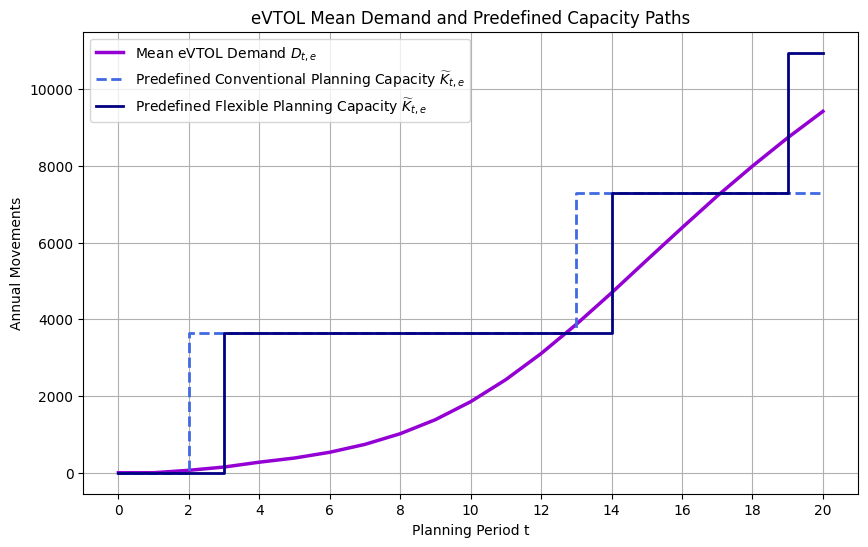

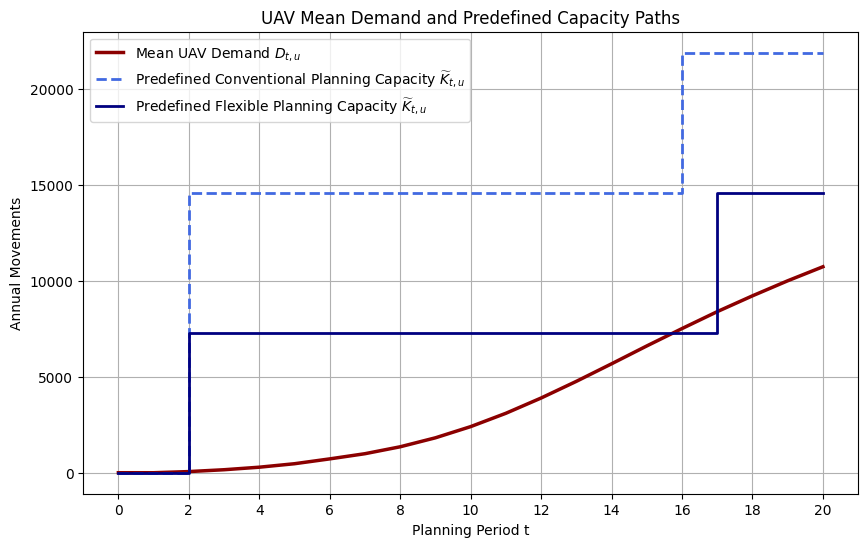

In [30]:
# Helper function: translate a flexible decision rule into an annual movement-capacity path

def capacity_paths_from_rule(demand_path, flex_params, k_per_unit):
    """Apply the flexible rule to a deterministic demand path and return annual movement capacity."""
    T = len(demand_path) - 1

    K_units_before = np.zeros(T + 1)
    K_units_after = np.zeros(T + 1)
    K_tilde_before = np.zeros(T + 1)

    # Initial installed capacity
    K_units_before[0] = flex_params["K0"]
    K_units_after[0] = flex_params["K0"]
    K_tilde_before[0] = K_units_before[0] * k_per_unit

    for t in range(1, T + 1):
        # Capacity available in planning period t
        K_units_before[t] = K_units_after[t - 1]
        K_tilde_before[t] = K_units_before[t] * k_per_unit

        # Expansion is decided in period t and becomes available in t + 1
        if K_tilde_before[t] - demand_path[t] < flex_params["theta1"]:
            K_units_after[t] = K_units_before[t] + flex_params["theta2"]
        else:
            K_units_after[t] = K_units_before[t]

    return K_tilde_before


# Mean demand paths used for the visual comparison
mean_evtol_demand = np.mean(scenarios_evtol_movements, axis=1)
mean_uav_demand = np.mean(scenarios_uav_movements, axis=1)

# Translate the predefined flexible policy into movement-capacity paths
flex_evtol = {
    "K0": flex_params["K0_e"],
    "theta1": flex_params["theta1_e"],
    "theta2": flex_params["theta2_e"],
}
flex_uav = {
    "K0": flex_params["K0_u"],
    "theta1": flex_params["theta1_u"],
    "theta2": flex_params["theta2_u"],
}

K_e_flex_mov = capacity_paths_from_rule(mean_evtol_demand, flex_evtol, params["k_e"])
K_u_flex_mov = capacity_paths_from_rule(mean_uav_demand, flex_uav, params["k_u"])

# Convert the predefined conventional schedules into annual movement capacities
K_e_conv_mov = np.array(predefined_K_e_schedule) * params["k_e"]
K_u_conv_mov = np.array(predefined_K_u_schedule) * params["k_u"]

planning_periods_predefined = np.arange(len(mean_evtol_demand))

# Plot 1: predefined eVTOL capacity paths
plt.figure(figsize=(10, 6))
plt.plot(
    planning_periods_predefined,
    mean_evtol_demand,
    linewidth=2.5,
    color="darkviolet",
    label=r"Mean eVTOL Demand $D_{t,e}$",
)
plt.step(
    planning_periods_predefined,
    K_e_conv_mov,
    where="post",
    linewidth=2,
    linestyle="--",
    color="royalblue",
    label=r"Predefined Conventional Planning Capacity $\widetilde{K}_{t,e}$",
)
plt.step(
    planning_periods_predefined,
    K_e_flex_mov,
    where="post",
    linewidth=2,
    color="navy",
    label=r"Predefined Flexible Planning Capacity $\widetilde{K}_{t,e}$",
)
plt.xlabel("Planning Period t")
plt.ylabel("Annual Movements")
plt.title("eVTOL Mean Demand and Predefined Capacity Paths")
plt.xticks(planning_periods_predefined[::2])
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

# Plot 2: predefined UAV capacity paths
plt.figure(figsize=(10, 6))
plt.plot(
    planning_periods_predefined,
    mean_uav_demand,
    linewidth=2.5,
    color="darkred",
    label=r"Mean UAV Demand $D_{t,u}$",
)
plt.step(
    planning_periods_predefined,
    K_u_conv_mov,
    where="post",
    linewidth=2,
    linestyle="--",
    color="royalblue",
    label=r"Predefined Conventional Planning Capacity $\widetilde{K}_{t,u}$",
)
plt.step(
    planning_periods_predefined,
    K_u_flex_mov,
    where="post",
    linewidth=2,
    color="navy",
    label=r"Predefined Flexible Planning Capacity $\widetilde{K}_{t,u}$",
)
plt.xlabel("Planning Period t")
plt.ylabel("Annual Movements")
plt.title("UAV Mean Demand and Predefined Capacity Paths")
plt.xticks(planning_periods_predefined[::2])
plt.legend(loc="upper left")
plt.grid(True)
plt.show()


##### 8.1.2 Average Annual Revenues, CAPEX, and OPEX


The average annual cash-flow components of the predefined approaches are compared across all simulated scenarios. This helps explain why one predifined approach creates more value than the other.

In [31]:
# Average annual cash-flow components for the predefined conventional and flexible approaches

def annual_cashflows_conventional_one_scenario(demand_e_path, demand_u_path, K_e_schedule, K_u_schedule, p):
    """Return revenues, CAPEX, and OPEX for one scenario under the conventional approach."""
    T = len(K_e_schedule) - 1

    revenues = np.zeros(T + 1)
    capex = np.zeros(T + 1)
    opex = np.zeros(T + 1)

    for t in range(T + 1):
        K_e = K_e_schedule[t]
        K_u = K_u_schedule[t]
        D_e = demand_e_path[t]
        D_u = demand_u_path[t]

        if t == 0:
            delta_K_e = K_e
            delta_K_u = K_u
        else:
            delta_K_e = K_e_schedule[t] - K_e_schedule[t - 1]
            delta_K_u = K_u_schedule[t] - K_u_schedule[t - 1]

        revenues[t] = revenue_t(D_e, D_u, K_e, K_u, p)
        capex[t] = capex_t(delta_K_e, delta_K_u, p)

        if t > 0:
            opex[t] = opex_t(D_e, D_u, K_e, K_u, p)

    return revenues, capex, opex


def annual_cashflows_flexible_one_scenario(demand_e_path, demand_u_path, flex, p):
    """Return revenues, CAPEX, and OPEX for one scenario under the flexible approach."""
    T = len(demand_e_path) - 1

    K_e_path = np.zeros(T + 1)
    K_u_path = np.zeros(T + 1)
    K_e_path[0] = flex["K0_e"]
    K_u_path[0] = flex["K0_u"]

    revenues = np.zeros(T + 1)
    capex = np.zeros(T + 1)
    opex = np.zeros(T + 1)

    for t in range(T + 1):
        K_e = K_e_path[t]
        K_u = K_u_path[t]
        D_e = demand_e_path[t]
        D_u = demand_u_path[t]
        revenues[t] = revenue_t(D_e, D_u, K_e, K_u, p)

        if t == 0:
            capex[t] = capex_t(K_e, K_u, p)
        else:
            delta_K_e = 0
            delta_K_u = 0

            if t < T:
                remaining_e = K_e * p["k_e"] - D_e
                remaining_u = K_u * p["k_u"] - D_u

                if remaining_e < flex["theta1_e"]:
                    delta_K_e = flex["theta2_e"]

                if remaining_u < flex["theta1_u"]:
                    delta_K_u = flex["theta2_u"]

                K_e_path[t + 1] = K_e + delta_K_e
                K_u_path[t + 1] = K_u + delta_K_u

            opex[t] = opex_t(D_e, D_u, K_e, K_u, p)
            capex[t] = capex_t(delta_K_e, delta_K_u, p)

    return revenues, capex, opex


def average_annual_cashflows_conventional(scenarios_evtol_movements, scenarios_uav_movements, K_e_schedule, K_u_schedule, p):
    """Average the annual cash-flow components across all scenarios for the conventional approach."""
    n_scenarios = scenarios_evtol_movements.shape[1]
    T = scenarios_evtol_movements.shape[0] - 1

    revenues_all = np.zeros((T + 1, n_scenarios))
    capex_all = np.zeros((T + 1, n_scenarios))
    opex_all = np.zeros((T + 1, n_scenarios))

    for s in range(n_scenarios):
        demand_e_path = scenarios_evtol_movements[:, s]
        demand_u_path = scenarios_uav_movements[:, s]
        revenues_all[:, s], capex_all[:, s], opex_all[:, s] = annual_cashflows_conventional_one_scenario(
            demand_e_path, demand_u_path, K_e_schedule, K_u_schedule, p
        )

    return revenues_all.mean(axis=1), capex_all.mean(axis=1), opex_all.mean(axis=1)


def average_annual_cashflows_flexible(scenarios_evtol_movements, scenarios_uav_movements, flex, p):
    """Average the annual cash-flow components across all scenarios for the flexible approach."""
    n_scenarios = scenarios_evtol_movements.shape[1]
    T = scenarios_evtol_movements.shape[0] - 1

    revenues_all = np.zeros((T + 1, n_scenarios))
    capex_all = np.zeros((T + 1, n_scenarios))
    opex_all = np.zeros((T + 1, n_scenarios))

    for s in range(n_scenarios):
        demand_e_path = scenarios_evtol_movements[:, s]
        demand_u_path = scenarios_uav_movements[:, s]
        revenues_all[:, s], capex_all[:, s], opex_all[:, s] = annual_cashflows_flexible_one_scenario(
            demand_e_path, demand_u_path, flex, p
        )

    return revenues_all.mean(axis=1), capex_all.mean(axis=1), opex_all.mean(axis=1)


# Compute average annual cash flows for the predefined approaches
avg_rev_conv, avg_capex_conv, avg_opex_conv = average_annual_cashflows_conventional(
    scenarios_evtol_movements,
    scenarios_uav_movements,
    predefined_K_e_schedule,
    predefined_K_u_schedule,
    params,
)

avg_rev_flex, avg_capex_flex, avg_opex_flex = average_annual_cashflows_flexible(
    scenarios_evtol_movements,
    scenarios_uav_movements,
    flex_params,
    params,
)

planning_periods_predefined_cashflows = np.arange(len(avg_rev_conv))


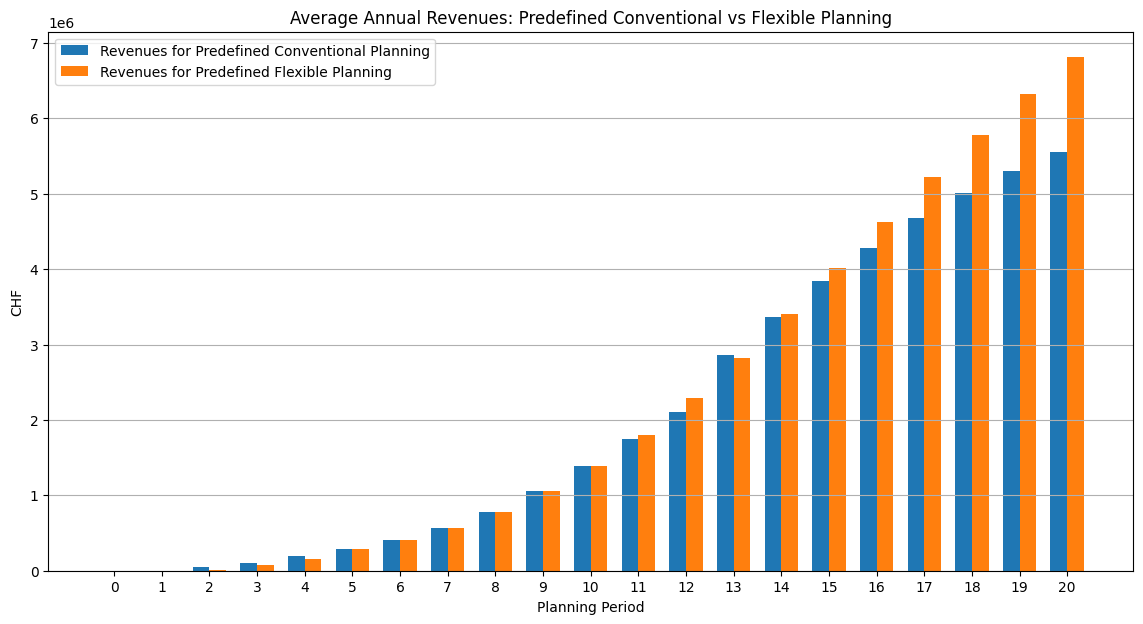

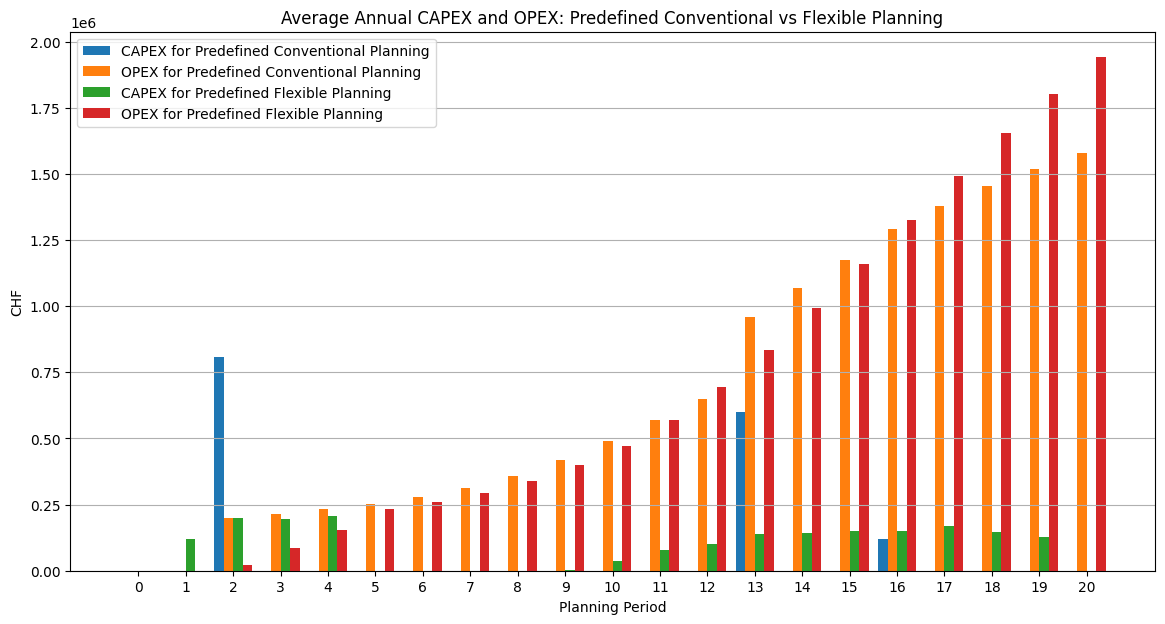

In [32]:
# Plot the average annual cash-flow comparison for the predefined approaches
width = 0.35
fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    planning_periods_predefined_cashflows - width / 2,
    avg_rev_conv,
    width,
    label="Revenues for Predefined Conventional Planning",
)
ax.bar(
    planning_periods_predefined_cashflows + width / 2,
    avg_rev_flex,
    width,
    label="Revenues for Predefined Flexible Planning",
)

ax.set_xlabel("Planning Period")
ax.set_ylabel("CHF")
ax.set_title("Average Annual Revenues: Predefined Conventional vs Flexible Planning")
ax.set_xticks(planning_periods_predefined_cashflows)
ax.grid(True, axis="y")
ax.legend()
plt.show()

width = 0.2
fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    planning_periods_predefined_cashflows - 1.5 * width,
    avg_capex_conv,
    width,
    label="CAPEX for Predefined Conventional Planning",
)
ax.bar(
    planning_periods_predefined_cashflows - 0.5 * width,
    avg_opex_conv,
    width,
    label="OPEX for Predefined Conventional Planning",
)
ax.bar(
    planning_periods_predefined_cashflows + 0.5 * width,
    avg_capex_flex,
    width,
    label="CAPEX for Predefined Flexible Planning",
)
ax.bar(
    planning_periods_predefined_cashflows + 1.5 * width,
    avg_opex_flex,
    width,
    label="OPEX for Predefined Flexible Planning",
)

ax.set_xlabel("Planning Period")
ax.set_ylabel("CHF")
ax.set_title("Average Annual CAPEX and OPEX: Predefined Conventional vs Flexible Planning")
ax.set_xticks(planning_periods_predefined_cashflows)
ax.grid(True, axis="y")
ax.legend()
plt.show()


#### 8.2 Comparison of the Best Approaches


The second comparison focuses on the ENPV-maximizing conventional and flexible approaches found in Chapter 7. Here the comparison is no longer between predefined benchmarks, but between the best candidate of each planning logic.

##### 8.2.1 Capacity Paths on the Mean Demand Path


The plots visualize how the best schedules of the conventional planning approach and the best decision rules of the flexible approach are applied on the mean demand for both eVTOL and UAV.

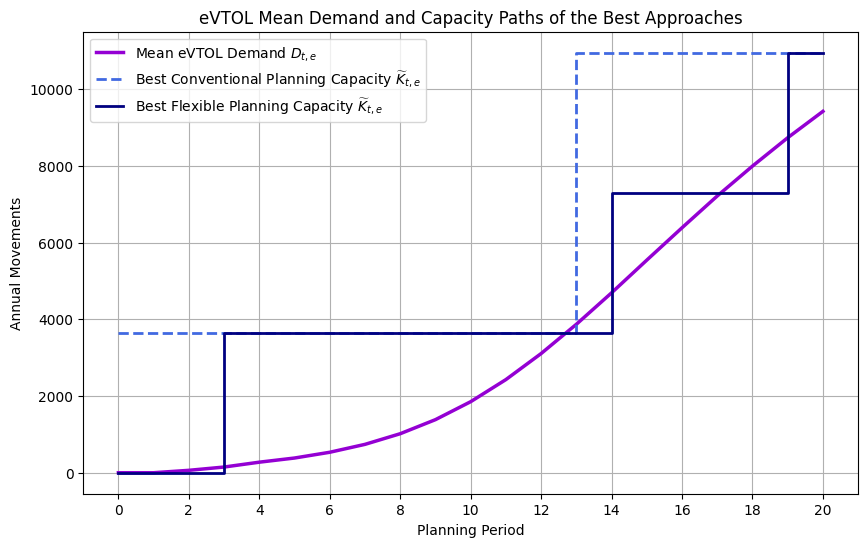

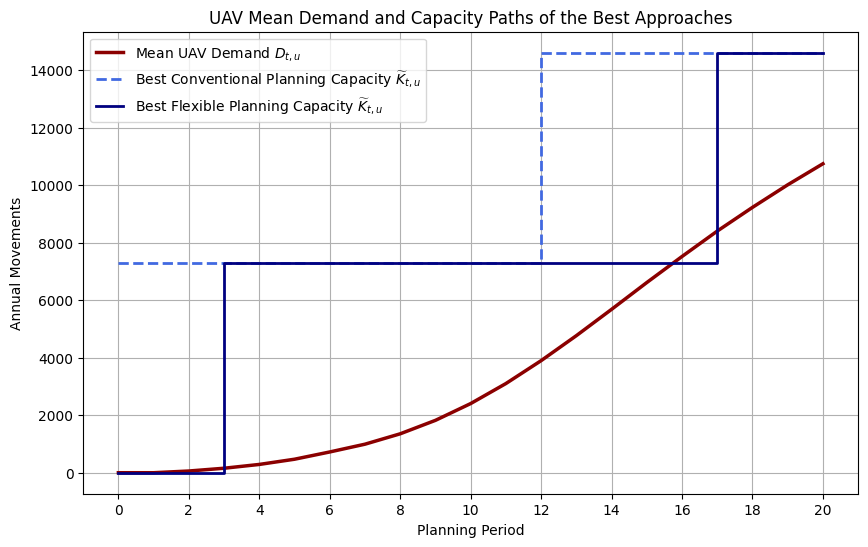

In [33]:
# Compare the optimized conventional and flexible capacity paths on the mean demand path
mean_evtol_demand = np.mean(scenarios_evtol_movements, axis=1)
mean_uav_demand = np.mean(scenarios_uav_movements, axis=1)

flex_evtol = {
    "K0": best_flex_params["K0_e"],
    "theta1": best_flex_params["theta1_e"],
    "theta2": best_flex_params["theta2_e"],
}
flex_uav = {
    "K0": best_flex_params["K0_u"],
    "theta1": best_flex_params["theta1_u"],
    "theta2": best_flex_params["theta2_u"],
}

K_e_flex_mov = capacity_paths_from_rule(mean_evtol_demand, flex_evtol, params["k_e"])
K_u_flex_mov = capacity_paths_from_rule(mean_uav_demand, flex_uav, params["k_u"])

K_e_conv_mov = np.array(best_conv_K_e) * params["k_e"]
K_u_conv_mov = np.array(best_conv_K_u) * params["k_u"]

planning_periods_best = np.arange(len(mean_evtol_demand))

# Plot 1: optimized eVTOL capacity paths
plt.figure(figsize=(10, 6))
plt.plot(
    planning_periods_best,
    mean_evtol_demand,
    linewidth=2.5,
    color="darkviolet",
    label=r"Mean eVTOL Demand $D_{t,e}$",
)
plt.step(
    planning_periods_best,
    K_e_conv_mov,
    where="post",
    linewidth=2,
    linestyle="--",
    color="royalblue",
    label=r"Best Conventional Planning Capacity $\widetilde{K}_{t,e}$",
)
plt.step(
    planning_periods_best,
    K_e_flex_mov,
    where="post",
    linewidth=2,
    color="navy",
    label=r"Best Flexible Planning Capacity $\widetilde{K}_{t,e}$",
)
plt.xlabel("Planning Period")
plt.ylabel("Annual Movements")
plt.title("eVTOL Mean Demand and Capacity Paths of the Best Approaches")
plt.xticks(planning_periods_best[::2])
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

# Plot 2: optimized UAV capacity paths
plt.figure(figsize=(10, 6))
plt.plot(
    planning_periods_best,
    mean_uav_demand,
    linewidth=2.5,
    color="darkred",
    label=r"Mean UAV Demand $D_{t,u}$",
)
plt.step(
    planning_periods_best,
    K_u_conv_mov,
    where="post",
    linewidth=2,
    linestyle="--",
    color="royalblue",
    label=r"Best Conventional Planning Capacity $\widetilde{K}_{t,u}$",
)
plt.step(
    planning_periods_best,
    K_u_flex_mov,
    where="post",
    linewidth=2,
    color="navy",
    label=r"Best Flexible Planning Capacity $\widetilde{K}_{t,u}$",
)
plt.xlabel("Planning Period")
plt.ylabel("Annual Movements")
plt.title("UAV Mean Demand and Capacity Paths of the Best Approaches")
plt.xticks(planning_periods_best[::2])
plt.legend(loc="upper left")
plt.grid(True)
plt.show()


##### 8.2.2 Annual Revenues, CAPEX, and OPEX on the Mean Demand Path

The average annual cash-flow components of the best approaches are compared across all simulated scenarios. This helps explain why one approach creates more value than the other.


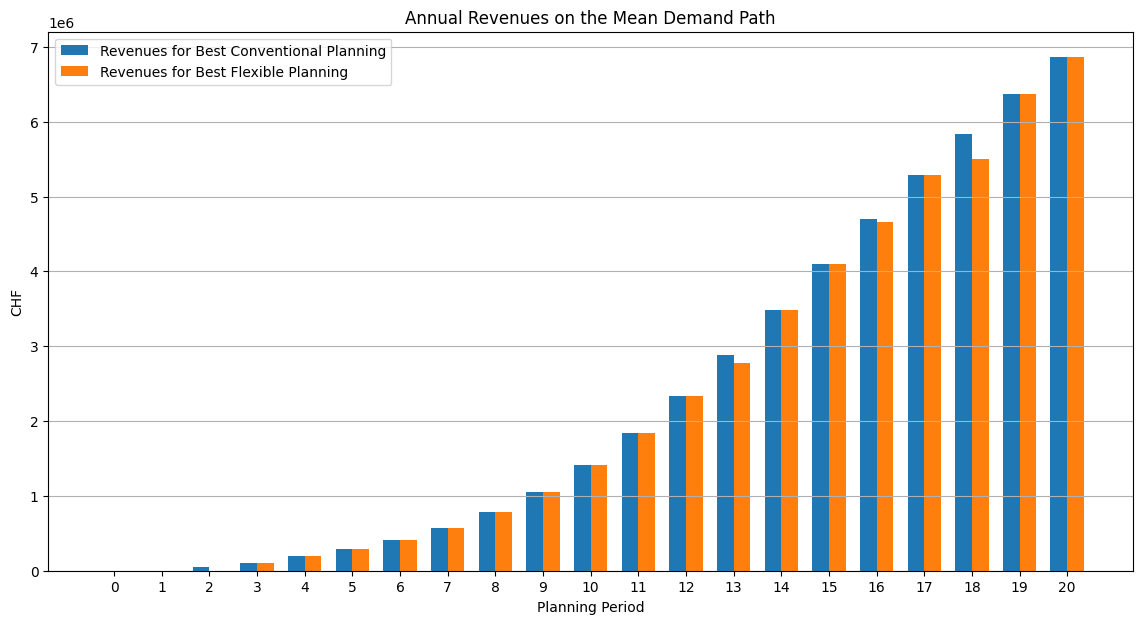

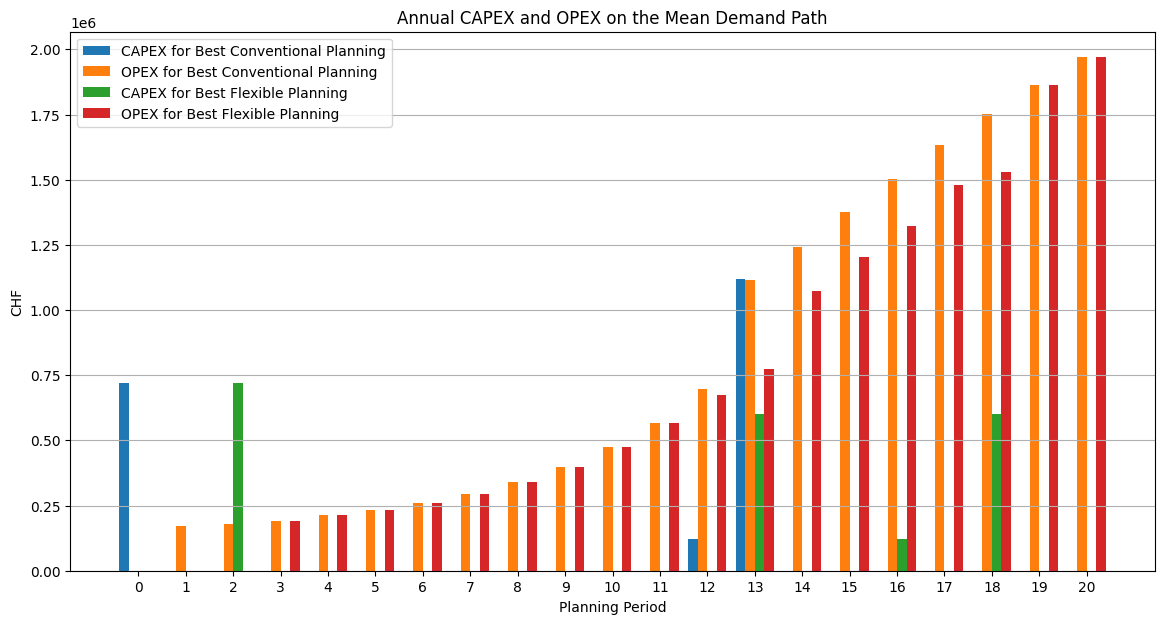

In [34]:
# Compare annual cash flows of the optimized approaches on the mean demand path
mean_demand_e_path = np.mean(scenarios_evtol_movements, axis=1)
mean_demand_u_path = np.mean(scenarios_uav_movements, axis=1)

rev_conv_mean, capex_conv_mean, opex_conv_mean = annual_cashflows_conventional_one_scenario(
    mean_demand_e_path,
    mean_demand_u_path,
    best_conv_K_e,
    best_conv_K_u,
    params,
)
rev_flex_mean, capex_flex_mean, opex_flex_mean = annual_cashflows_flexible_one_scenario(
    mean_demand_e_path,
    mean_demand_u_path,
    best_flex_params,
    params,
)

planning_periods_best_cashflows = np.arange(len(rev_conv_mean))

# Plot 1: annual revenues of the optimized approaches
width = 0.35
fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    planning_periods_best_cashflows - width / 2,
    rev_conv_mean,
    width,
    label="Revenues for Best Conventional Planning",
)
ax.bar(
    planning_periods_best_cashflows + width / 2,
    rev_flex_mean,
    width,
    label="Revenues for Best Flexible Planning",
)

ax.set_xlabel("Planning Period")
ax.set_ylabel("CHF")
ax.set_title("Annual Revenues on the Mean Demand Path")
ax.set_xticks(planning_periods_best_cashflows)
ax.grid(True, axis="y")
ax.legend()
plt.show()

# Plot 2: annual CAPEX and OPEX of the optimized approaches
width = 0.2
fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    planning_periods_best_cashflows - 1.5 * width,
    capex_conv_mean,
    width,
    label="CAPEX for Best Conventional Planning",
)
ax.bar(
    planning_periods_best_cashflows - 0.5 * width,
    opex_conv_mean,
    width,
    label="OPEX for Best Conventional Planning",
)
ax.bar(
    planning_periods_best_cashflows + 0.5 * width,
    capex_flex_mean,
    width,
    label="CAPEX for Best Flexible Planning",
)
ax.bar(
    planning_periods_best_cashflows + 1.5 * width,
    opex_flex_mean,
    width,
    label="OPEX for Best Flexible Planning",
)

ax.set_xlabel("Planning Period")
ax.set_ylabel("CHF")
ax.set_title("Annual CAPEX and OPEX on the Mean Demand Path")
ax.set_xticks(planning_periods_best_cashflows)
ax.grid(True, axis="y")
ax.legend()
plt.show()


#### 8.3 ECDF Target Curves and Optimal ENPV Values

The final target curves are shown as empirical cumulative distribution functions (ECDFs) of the NPVs across all simulated scenarios. The plot compares the NPV distributions of the best conventional and best flexible approaches and marks their corresponding ENPV values with vertical dashed lines.


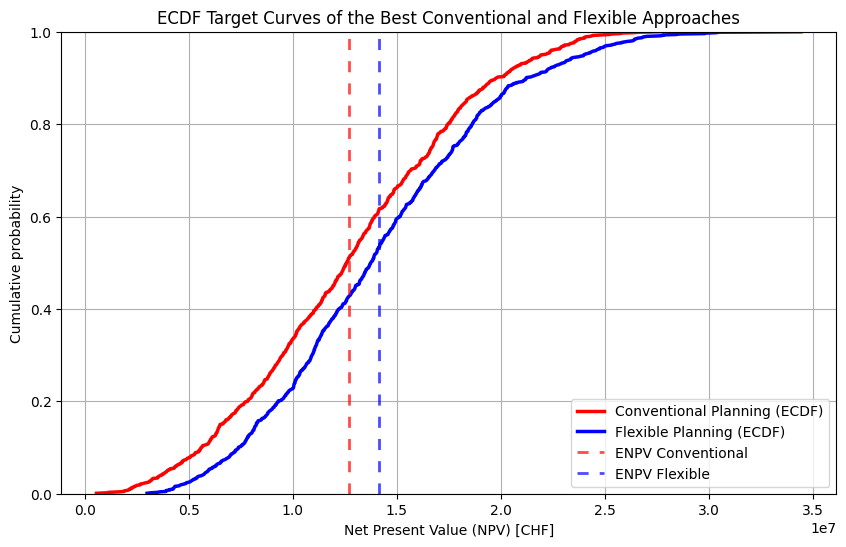

In [35]:
# Final target curves: ECDFs of the NPVs for the best conventional and best flexible approaches
optimal_enpv_conv, optimal_npvs_conv = enpv_conventional(
    scenarios_evtol_movements,
    scenarios_uav_movements,
    best_conv_K_e,
    best_conv_K_u,
    params,
)
optimal_enpv_flex, optimal_npvs_flex = enpv_flexible(
    scenarios_evtol_movements,
    scenarios_uav_movements,
    best_flex_params,
    params,
)

# Summary table of the optimal ENPV values
optimal_enpv_comparison = pd.DataFrame(
    {
        "Approach": ["Best conventional", "Best flexible"],
        "Optimal ENPV": [format_chf(optimal_enpv_conv), format_chf(optimal_enpv_flex)],
    }
)
optimal_enpv_comparison

# Helper function for the empirical cumulative distribution function

def ecdf(values):
    """Return sorted values and their empirical cumulative probabilities."""
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


x_conv, y_conv = ecdf(optimal_npvs_conv)
x_flex, y_flex = ecdf(optimal_npvs_flex)

# Plot the ECDF target curves and the ENPV reference lines
plt.figure(figsize=(10, 6))
plt.plot(x_conv, y_conv, color="red", linewidth=2.5, label="Conventional Planning (ECDF)")
plt.plot(x_flex, y_flex, color="blue", linewidth=2.5, label="Flexible Planning (ECDF)")

plt.axvline(
    optimal_enpv_conv,
    color="red",
    linestyle=(0, (4, 4)),
    linewidth=2,
    alpha=0.7,
    label="ENPV Conventional",
)
plt.axvline(
    optimal_enpv_flex,
    color="blue",
    linestyle=(0, (4, 4)),
    linewidth=2,
    alpha=0.7,
    label="ENPV Flexible",
)

plt.xlabel("Net Present Value (NPV) [CHF]")
plt.ylabel("Cumulative probability")
plt.title("ECDF Target Curves of the Best Conventional and Flexible Approaches")
plt.ylim(0, 1)
plt.grid(True)
plt.legend(loc="lower right")
plt.show()
